# Handle Class Imbalance — Hybrid Sampling (SMOTEENN vs SMOTETomek) vs Adjusted Model

**Hybrid sampling** = oversampling (SMOTE) lalu pembersihan mayoritas. Dua varian dibandingkan: **SMOTEENN** (SMOTE + Edited Nearest Neighbours) dan **SMOTETomek** (SMOTE + Tomek Links). Keduanya diadu dengan baseline **adjusted** (class_weight balanced) pada 7 model identik. Resampling hanya pada **fold training** (anti-bocor).

Dataset `Dataset_TehHijau.csv` **ber-grup**: 274 `Sampling_ID`. CV memakai `StratifiedKFold(groups=Sampling_ID)`; metrik andalan **balanced accuracy** & **macro-F1**.

> ⚠️ **Runtime:** hybrid meng-oversample ke level mayoritas (~23k baris/fold) lalu cleaning -> SVC `probability=True` sangat lambat, dan tiap model dijalankan untuk **tiap** teknik. Komentari model/teknik yang tak perlu di `MODELS`/`RESAMPLERS`.

In [1]:
!python -m pip install -q numpy pandas scikit-learn imbalanced-learn \
    xgboost catboost matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

cwd = os.path.abspath(os.getcwd())
project_root = cwd.split('codes')[0] + 'codes'
sys.path.append(os.path.abspath(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [3]:
import importlib

def reload_package(package_name):
    for name in sorted([n for n in sys.modules if n.startswith(package_name)], reverse=True):
        importlib.reload(sys.modules[name])

reload_package('utils')

## 1. Konfigurasi

In [4]:
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE
from utils.imbalance_eval import (
    evaluate_cv, resample_for_viz, make_resample_pipeline, BEST_PARAMS, MODEL_ORDER)

dataset_path = os.path.join(project_root, 'dataset', 'Dataset_TehHijau.csv')

feature_cols = [
    'MQ3', 'TGS822', 'TGS2602', 'MQ5', 'MQ138', 'TGS2620',
    'TGS813', 'TGS2600', 'TGS2611', 'TGS2603', 'Humidity', 'Celsius',
]
target_col = 'Kategori'
group_col  = 'Sampling_ID'

# Teknik resampling yang dibandingkan (urutan dipakai di tabel/plot).
# Komentari yang tak perlu untuk menghemat waktu.
RESAMPLERS = {
    'SMOTEENN':   SMOTEENN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
    'SMOTE':     SMOTE(random_state=42, k_neighbors=5),
}
STRATEGY = 'hybrid'

XGB_DEVICE   = 'cuda'   # ganti 'cpu' kalau tak ada GPU
CAT_TASK_TYPE = 'GPU'   # ganti 'CPU' kalau tak ada GPU

MODELS = list(MODEL_ORDER)
print('Models:', MODELS)
print('Teknik:', list(RESAMPLERS.keys()))

OUT_DIR = os.path.join(cwd, 'results', STRATEGY)
os.makedirs(OUT_DIR, exist_ok=True)
print('Output:', OUT_DIR)

Models: ['SVC Linear', 'SVC Sigmoid', 'SVC Poly', 'SVC RBF', 'XGBoost GBTree', 'XGBoost Dart', 'CatBoost']
Teknik: ['SMOTEENN', 'SMOTETomek', 'SMOTE']
Output: c:\`Bioinformatics\quantum-gesang\codes\notebooks\handle_imbalance\results\hybrid


## 2. Muat Data & Distribusi Kelas

In [5]:
data = pd.read_csv(dataset_path)
print('shape:', data.shape, '| n Sampling_ID:', data[group_col].nunique())
data[target_col].value_counts().sort_index()

shape: (10409, 130) | n Sampling_ID: 274


Kategori
A     927
B     229
C    2287
D    2317
E    4649
Name: count, dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder

X = data[feature_cols]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(data[target_col])
groups = data[group_col].values
labels = np.unique(y)
class_names = list(label_encoder.classes_)
print('X:', X.shape, '| classes:', class_names)

X: (10409, 12) | classes: ['A', 'B', 'C', 'D', 'E']


## 3. PCA — jumlah komponen optimal (95% varians)

In [7]:
from sklearn.decomposition import PCA

_pca = PCA(n_components=X.shape[1]).fit(X)
cumvar = np.cumsum(_pca.explained_variance_ratio_)
n_optimal = int(np.argmax(cumvar >= 0.95) + 1)
print('n_optimal =', n_optimal)

n_optimal = 4


## 4. Komposisi Dataset — Sebelum vs Sesudah (tiap teknik)

Jumlah baris per kelas pada 1 fold training, untuk tiap teknik. Histogram tidak terpengaruh PCA; scatter PC1–PC2 menampilkan sebaran fitur.

Komposisi kelas (1 fold training):
   Sebelum  SMOTEENN  SMOTETomek  SMOTE
A      742      3678        3716   3719
B      183      3719        3719   3719
C     1830      3612        3713   3719
D     1853      3631        3716   3719
E     3719      3615        3713   3719


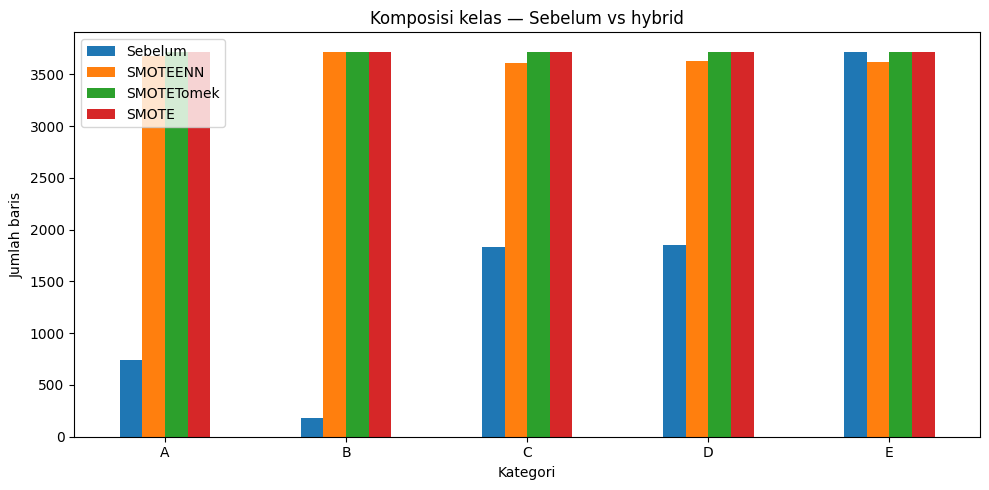

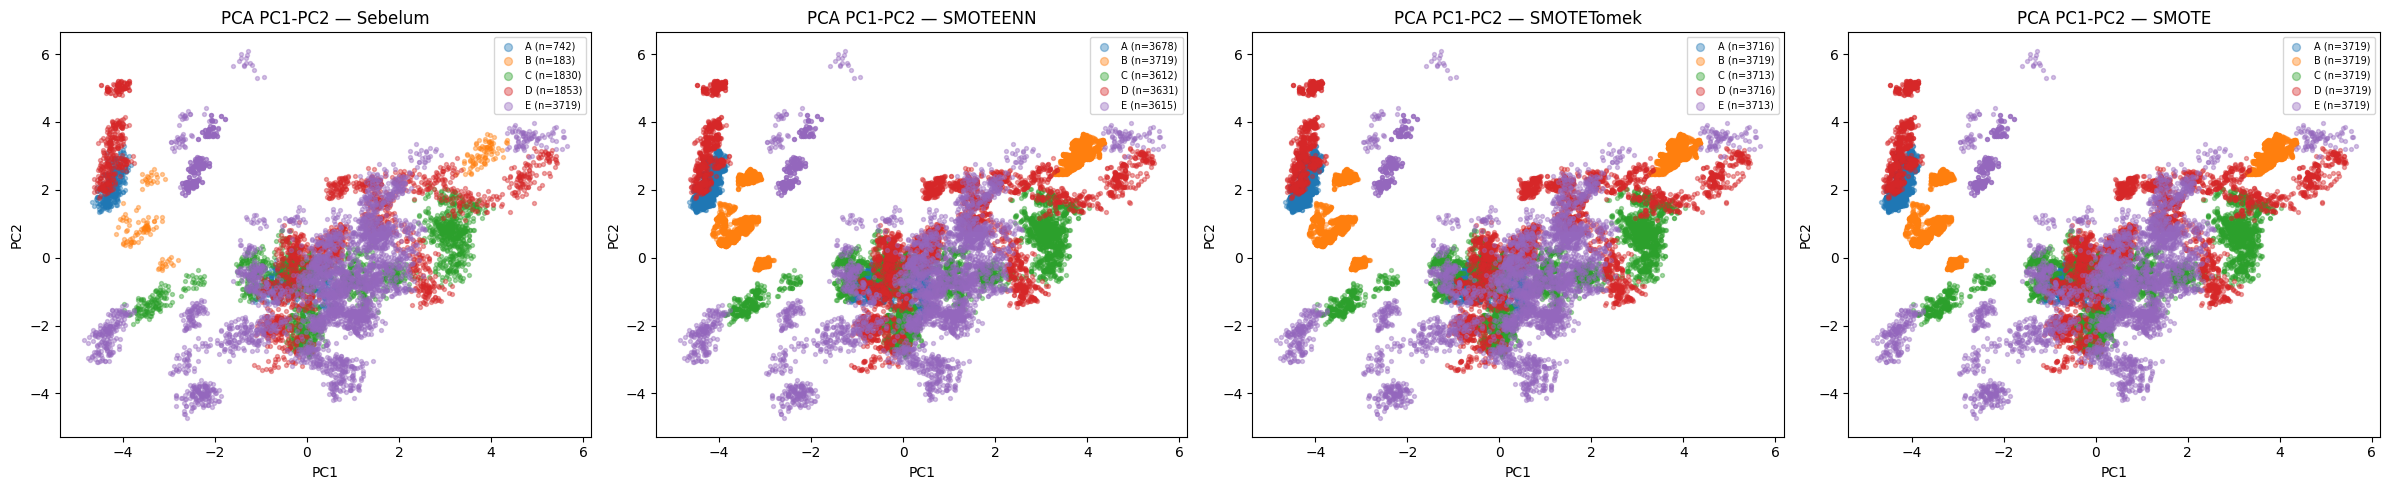

In [8]:
from collections import Counter

comp = pd.DataFrame(index=class_names)
before_xy = None
scatters = []
for tech, R in RESAMPLERS.items():
    v = resample_for_viz(X, y, groups, R, n_optimal, fold_index=0)
    if before_xy is None:
        before_xy = (v['X_before'], v['y_before'])
        comp['Sebelum'] = [Counter(v['y_before']).get(i, 0) for i in labels]
    comp[tech] = [Counter(v['y_after']).get(i, 0) for i in labels]
    scatters.append((tech, v['X_after'], v['y_after']))
print('Komposisi kelas (1 fold training):'); print(comp)
comp.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_composition.csv'))

ax = comp.plot(kind='bar', figsize=(10, 5))
ax.set_title(f'Komposisi kelas — Sebelum vs {STRATEGY}')
ax.set_xlabel('Kategori'); ax.set_ylabel('Jumlah baris'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_composition_bar.png'), dpi=130, bbox_inches='tight')
plt.show()

cmap = plt.cm.tab10
panels = [('Sebelum', before_xy[0], before_xy[1])] + [(t, Xa, ya) for (t, Xa, ya) in scatters]
ncols = len(panels)
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
axes = np.atleast_1d(axes)
for ax, (ttl, Xp, yp) in zip(axes, panels):
    for i, cn in enumerate(class_names):
        m = yp == labels[i]
        ax.scatter(Xp[m, 0], Xp[m, 1], s=8, alpha=0.4, color=cmap(i), label=f'{cn} (n={int(m.sum())})')
    ax.set_title(f'PCA PC1-PC2 — {ttl}'); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=7, markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_composition_scatter.png'), dpi=130, bbox_inches='tight')
plt.show()

## 5. Evaluasi: Adjusted vs tiap teknik hybrid

Tiap model dijalankan untuk **adjusted** (balanced, tanpa resampling) lalu **tiap teknik** (resampling di fold training, classifier tanpa bobot).

In [9]:
import time
from pathlib import Path
from datetime import datetime

log_path = Path(OUT_DIR) / f'{STRATEGY}_run.log'
log_path.write_text('', encoding='utf-8')

def log(msg=''):
    print(msg)
    with open(log_path, 'a', encoding='utf-8') as f:
        f.write(str(msg) + '\n')

log(f'Started: {datetime.now().isoformat(timespec="seconds")} | strategy={STRATEGY}')

common = dict(n_optimal=n_optimal, labels=labels,
              xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, log=log)
STRATEGIES = ['adjusted'] + list(RESAMPLERS.keys())

all_results = []
for name in MODELS:
    params = BEST_PARAMS[name]
    for strat in STRATEGIES:
        log(f'\n=== {name} | {strat} ===')
        try:
            if strat == 'adjusted':
                r = evaluate_cv(X, y, groups, name, params, mode='adjusted', **common)
            else:
                r = evaluate_cv(X, y, groups, name, params, mode='resample',
                                resampler=RESAMPLERS[strat], **common)
            r['strategy'] = strat
            all_results.append(r)
        except Exception as e:
            log(f'  FAILED [{name} | {strat}] -> {type(e).__name__}: {e}')
log(f'\nDone. {len(all_results)} (model x strategi).')

Started: 2026-06-07T07:32:00 | strategy=hybrid

=== SVC Linear | adjusted ===
    F1 -> Acc=0.3895 | BalAcc=0.4873 | MacroF1=0.3593 | AUROC=0.6943 | PRAUC=0.4838
    F2 -> Acc=0.3963 | BalAcc=0.5010 | MacroF1=0.3644 | AUROC=0.7083 | PRAUC=0.4997
    F3 -> Acc=0.3799 | BalAcc=0.4855 | MacroF1=0.3519 | AUROC=0.6795 | PRAUC=0.4723
    F4 -> Acc=0.4015 | BalAcc=0.5135 | MacroF1=0.3741 | AUROC=0.6925 | PRAUC=0.4840
    F5 -> Acc=0.3763 | BalAcc=0.5018 | MacroF1=0.3527 | AUROC=0.6848 | PRAUC=0.4729
  OK [SVC Linear | adjusted] BalAcc=0.4978 MacroF1=0.3605 AUROC=0.6919 MCC=0.2529 (75.2s)

=== SVC Linear | SMOTEENN ===
    F1 -> Acc=0.3939 | BalAcc=0.5072 | MacroF1=0.3660 | AUROC=0.7024 | PRAUC=0.4879
    F2 -> Acc=0.4030 | BalAcc=0.5247 | MacroF1=0.3740 | AUROC=0.7170 | PRAUC=0.5044
    F3 -> Acc=0.3866 | BalAcc=0.5065 | MacroF1=0.3600 | AUROC=0.6923 | PRAUC=0.4828
    F4 -> Acc=0.4135 | BalAcc=0.5423 | MacroF1=0.3897 | AUROC=0.7012 | PRAUC=0.4947
    F5 -> Acc=0.3806 | BalAcc=0.5188 | MacroF

## 6. Tabel Perbandingan

In [10]:
metric_cols = ['balanced_accuracy', 'macro_f1', 'accuracy', 'weighted_f1',
               'precision', 'recall', 'roc_auc', 'pr_auc', 'mcc', 'execution_time']
rows = [{'Model': r['model'], 'Strategy': r['strategy'],
         **{m: r[m] for m in metric_cols}} for r in all_results]
res_df = pd.DataFrame(rows)
res_df.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_metrics_long.csv'), index=False)
res_df.style.format({m: '{:.4f}' for m in metric_cols})

,Model,Strategy,balanced_accuracy,macro_f1,accuracy,weighted_f1,precision,recall,roc_auc,pr_auc,mcc,execution_time
0,SVC Linear,adjusted,0.4978,0.3605,0.3887,0.3987,0.5599,0.3887,0.6919,0.4826,0.2529,75.2389
1,SVC Linear,SMOTEENN,0.5199,0.3696,0.3955,0.4036,0.5698,0.3955,0.7019,0.4910,0.2688,231.9958
2,SVC Linear,SMOTETomek,0.5099,0.3671,0.3943,0.4032,0.5638,0.3943,0.7016,0.4913,0.2620,258.3319
3,SVC Linear,SMOTE,0.5078,0.3662,0.3938,0.4031,0.5631,0.3938,0.7016,0.4914,0.2607,256.7139
4,SVC Sigmoid,adjusted,0.2482,0.1685,0.1709,0.1932,0.3501,0.1709,0.6330,0.3933,0.0440,112.3215
5,SVC Sigmoid,SMOTEENN,0.2350,0.1684,0.1760,0.2045,0.3392,0.1760,0.6316,0.3820,0.0353,388.5319
6,SVC Sigmoid,SMOTETomek,0.2364,0.1705,0.1781,0.2069,0.3390,0.1781,0.6281,0.3796,0.0363,398.8645
7,SVC Sigmoid,SMOTE,0.2356,0.1705,0.1781,0.2070,0.3386,0.1781,0.6286,0.3803,0.0360,418.8004
8,SVC Poly,adjusted,0.5177,0.4029,0.4292,0.4151,0.7068,0.4292,0.7787,0.6084,0.3230,86.3316
9,SVC Poly,SMOTEENN,0.5269,0.4232,0.4520,0.4488,0.6214,0.4520,0.7779,0.6260,0.3179,249.0059


In [11]:
# Strategi terbaik per model (balanced_accuracy)
best = (res_df.sort_values('balanced_accuracy', ascending=False)
        .groupby('Model', sort=False).first()[['Strategy', 'balanced_accuracy', 'macro_f1', 'roc_auc', 'mcc']])
best = best.reindex([m for m in MODELS if m in best.index])
best.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_best_per_model.csv'))
log('Strategi terbaik per model (balanced_accuracy):')
for m, row in best.iterrows():
    log(f"  {m:<16s} -> {row['Strategy']:<12s} BalAcc={row['balanced_accuracy']:.4f} MacroF1={row['macro_f1']:.4f}")
best

Strategi terbaik per model (balanced_accuracy):
  SVC Linear       -> SMOTEENN     BalAcc=0.5199 MacroF1=0.3696
  SVC Sigmoid      -> adjusted     BalAcc=0.2482 MacroF1=0.1685
  SVC Poly         -> SMOTE        BalAcc=0.5344 MacroF1=0.4394
  SVC RBF          -> SMOTEENN     BalAcc=0.8166 MacroF1=0.7490
  XGBoost GBTree   -> SMOTEENN     BalAcc=0.7387 MacroF1=0.6140
  XGBoost Dart     -> SMOTE        BalAcc=0.6937 MacroF1=0.5360
  CatBoost         -> adjusted     BalAcc=0.7571 MacroF1=0.6293


,Strategy,balanced_accuracy,macro_f1,roc_auc,mcc
Model,,,,,
SVC Linear,SMOTEENN,0.5199,0.3696,0.7019,0.2688
SVC Sigmoid,adjusted,0.2482,0.1685,0.6330,0.0440
SVC Poly,SMOTE,0.5344,0.4394,0.7770,0.3328
SVC RBF,SMOTEENN,0.8166,0.7490,0.9367,0.6578
XGBoost GBTree,SMOTEENN,0.7387,0.6140,0.8977,0.5419
XGBoost Dart,SMOTE,0.6937,0.5360,0.8743,0.4654
CatBoost,adjusted,0.7571,0.6293,0.8855,0.5486


## 7. Visual: Balanced Accuracy & Macro-F1 per strategi

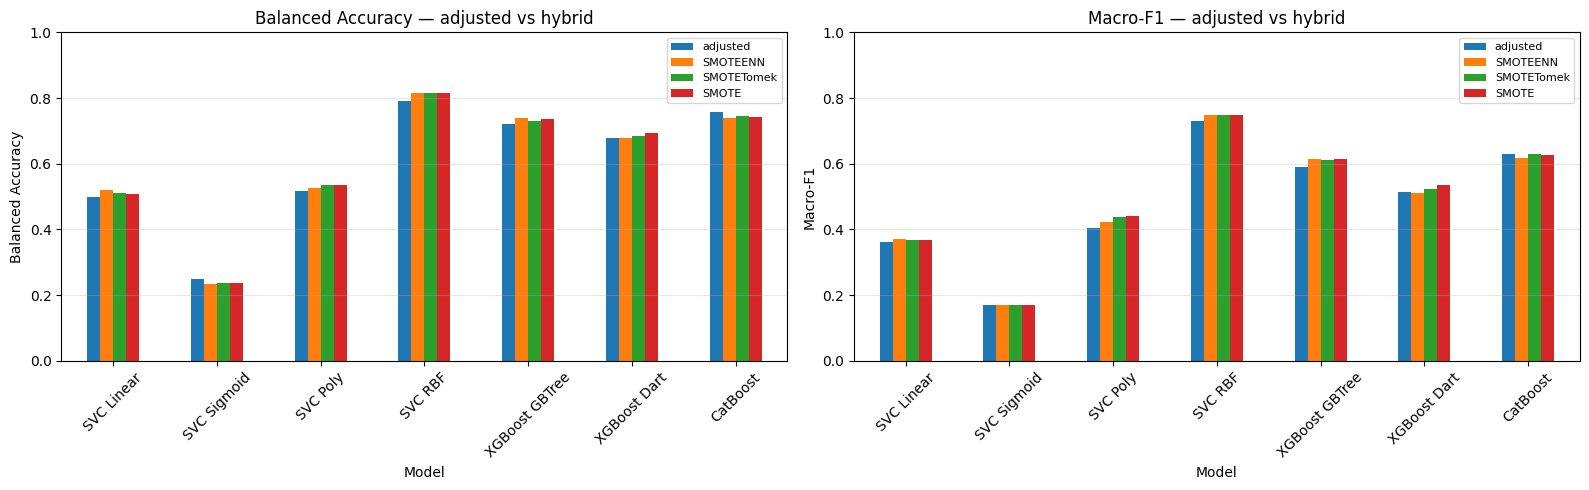

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, metric, title in zip(axes, ['balanced_accuracy', 'macro_f1'],
                             ['Balanced Accuracy', 'Macro-F1']):
    sub = res_df.pivot(index='Model', columns='Strategy', values=metric)
    sub = sub.reindex(index=[m for m in MODELS if m in sub.index],
                      columns=[s for s in STRATEGIES if s in sub.columns])
    sub.plot(kind='bar', ax=ax)
    ax.set_title(f'{title} — adjusted vs {STRATEGY}'); ax.set_ylabel(title)
    ax.set_ylim(0, 1.0); ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_bar_compare.png'), dpi=130, bbox_inches='tight')
plt.show()

## 8. Confusion Matrix Out-of-Fold

Kolom = strategi (adjusted + tiap teknik); baris = model.

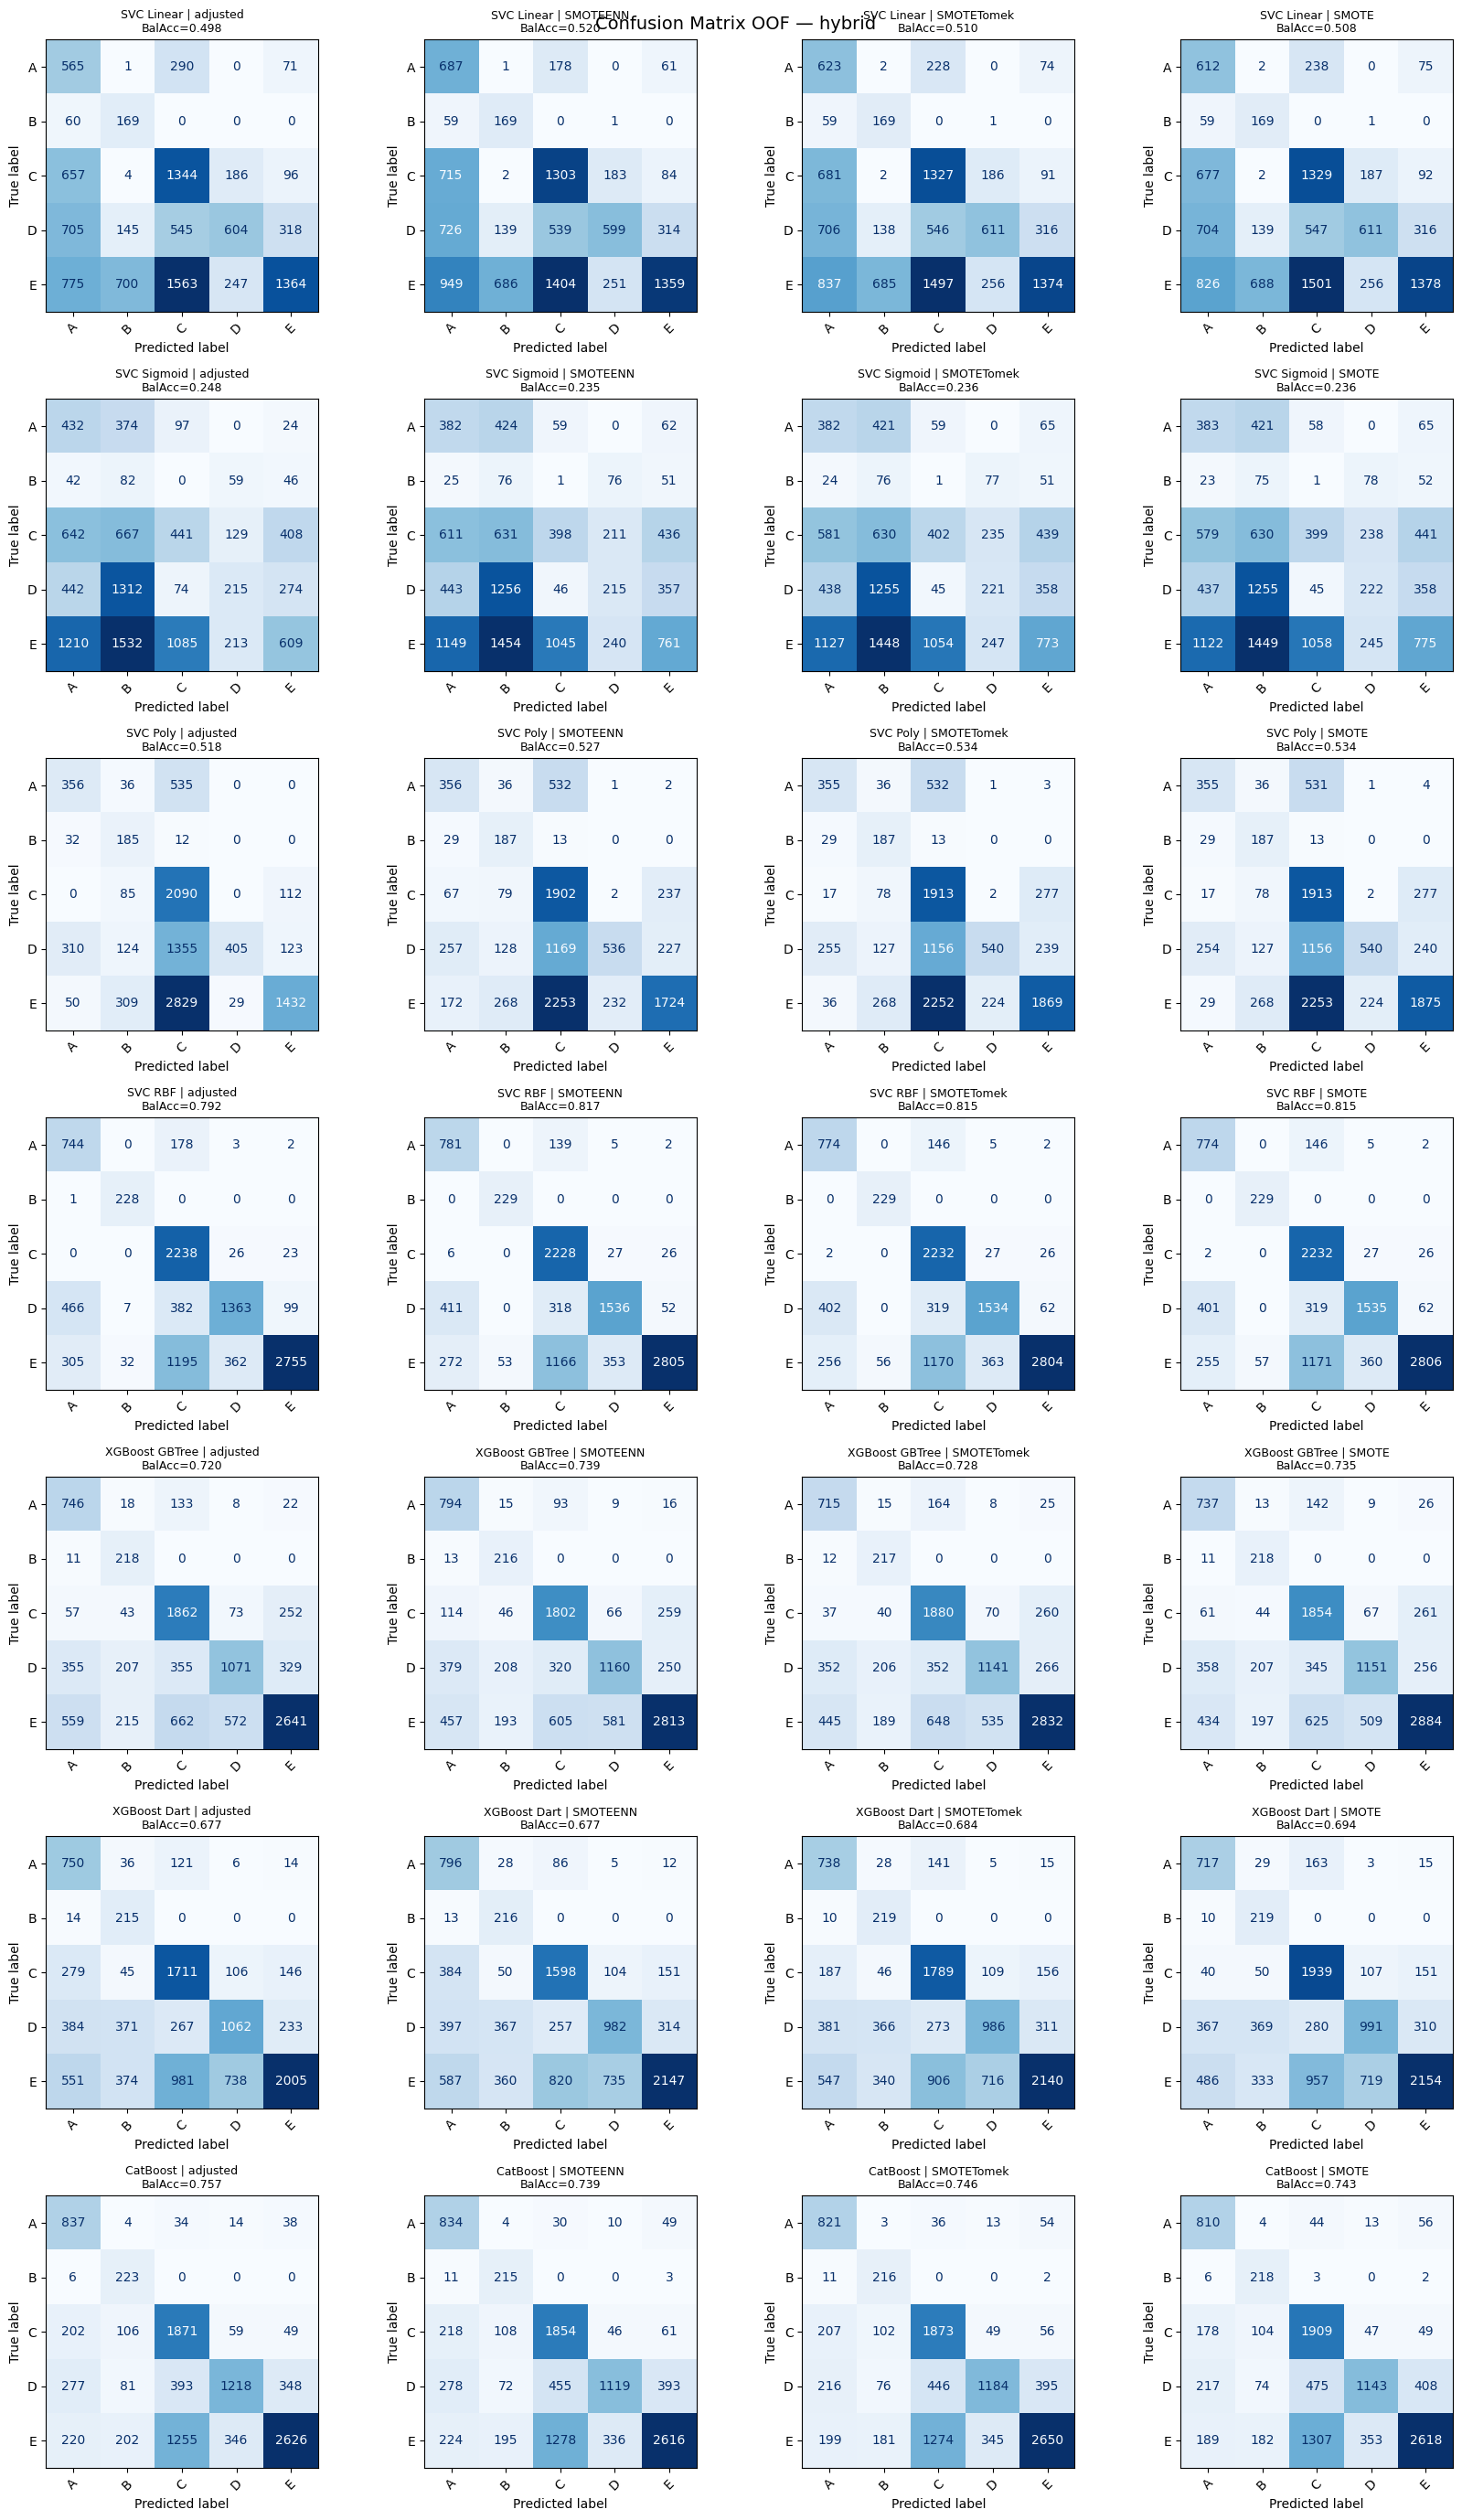

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

by_model = {}
for r in all_results:
    by_model.setdefault(r['model'], {})[r['strategy']] = r
ordered = [m for m in MODELS if m in by_model]

ncols = len(STRATEGIES); nrows = len(ordered)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)
for i, name in enumerate(ordered):
    for j, strat in enumerate(STRATEGIES):
        ax = axes[i, j]; r = by_model[name].get(strat)
        if r is None:
            ax.axis('off'); continue
        cm = confusion_matrix(r['y_true'], r['y_pred'], labels=labels)
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=ax, cmap='Blues', colorbar=False, values_format='d')
        ax.set_title(f"{name} | {strat}\nBalAcc={r['balanced_accuracy']:.3f}", fontsize=9)
        ax.tick_params(axis='x', rotation=45)
fig.suptitle(f'Confusion Matrix OOF — {STRATEGY}', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()

In [14]:
for name in ordered:
    for strat in STRATEGIES:
        r = by_model[name].get(strat)
        if r is None: continue
        log('=' * 64); log(f'{name} | {strat}')
        log(classification_report(r['y_true'], r['y_pred'], labels=labels,
                                  target_names=class_names, zero_division=0))

SVC Linear | adjusted
              precision    recall  f1-score   support

           A       0.20      0.61      0.31       927
           B       0.17      0.74      0.27       229
           C       0.36      0.59      0.45      2287
           D       0.58      0.26      0.36      2317
           E       0.74      0.29      0.42      4649

    accuracy                           0.39     10409
   macro avg       0.41      0.50      0.36     10409
weighted avg       0.56      0.39      0.40     10409

SVC Linear | SMOTEENN
              precision    recall  f1-score   support

           A       0.22      0.74      0.34       927
           B       0.17      0.74      0.28       229
           C       0.38      0.57      0.46      2287
           D       0.58      0.26      0.36      2317
           E       0.75      0.29      0.42      4649

    accuracy                           0.40     10409
   macro avg       0.42      0.52      0.37     10409
weighted avg       0.57      0.40

## 9. Learning Curve — cek Overfit / Underfit (tiap teknik)

Grid: baris = model, kolom = teknik. Mode resample (classifier tanpa balanced). `probability=True` dipakai karena `scoring='neg_log_loss'` butuh `predict_proba` — tanpa ini SVC tak punya `predict_proba` sehingga skornya NaN dan kurva SVC kosong.

In [15]:
from sklearn.model_selection import learning_curve, StratifiedKFold

LC_TRAIN_SIZES = np.linspace(0.2, 1.0, 5)
LC_CV = 5; LC_SCORING = 'neg_log_loss'; LC_STATE = 42
groups_arr = np.asarray(groups)
techs = list(RESAMPLERS.keys())

lc = {}
for name in MODELS:
    for tech in techs:
        log(f'  > LC: {name} | {tech} ...')
        try:
            pipe = make_resample_pipeline(name, BEST_PARAMS[name], RESAMPLERS[tech],
                                          n_optimal, xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, probability=True)
            ts, tr, va = learning_curve(
                pipe, X, y, train_sizes=LC_TRAIN_SIZES,
                cv=StratifiedKFold(LC_CV, shuffle=True, random_state=LC_STATE),
                scoring=LC_SCORING, n_jobs=1, shuffle=True, random_state=LC_STATE)
            lc[(name, tech)] = (ts, tr.mean(1), tr.std(1), va.mean(1), va.std(1))
        except Exception as e:
            log(f'    FAILED [{name}|{tech}] -> {type(e).__name__}: {e}')
log(f'LC selesai: {len(lc)} kurva.')

  > LC: SVC Linear | SMOTEENN ...
  > LC: SVC Linear | SMOTETomek ...
  > LC: SVC Linear | SMOTE ...
  > LC: SVC Sigmoid | SMOTEENN ...
  > LC: SVC Sigmoid | SMOTETomek ...
  > LC: SVC Sigmoid | SMOTE ...
  > LC: SVC Poly | SMOTEENN ...
  > LC: SVC Poly | SMOTETomek ...
  > LC: SVC Poly | SMOTE ...
  > LC: SVC RBF | SMOTEENN ...
  > LC: SVC RBF | SMOTETomek ...
  > LC: SVC RBF | SMOTE ...
  > LC: XGBoost GBTree | SMOTEENN ...
  > LC: XGBoost GBTree | SMOTETomek ...
  > LC: XGBoost GBTree | SMOTE ...
  > LC: XGBoost Dart | SMOTEENN ...
  > LC: XGBoost Dart | SMOTETomek ...
  > LC: XGBoost Dart | SMOTE ...
  > LC: CatBoost | SMOTEENN ...
  > LC: CatBoost | SMOTETomek ...
  > LC: CatBoost | SMOTE ...
LC selesai: 21 kurva.


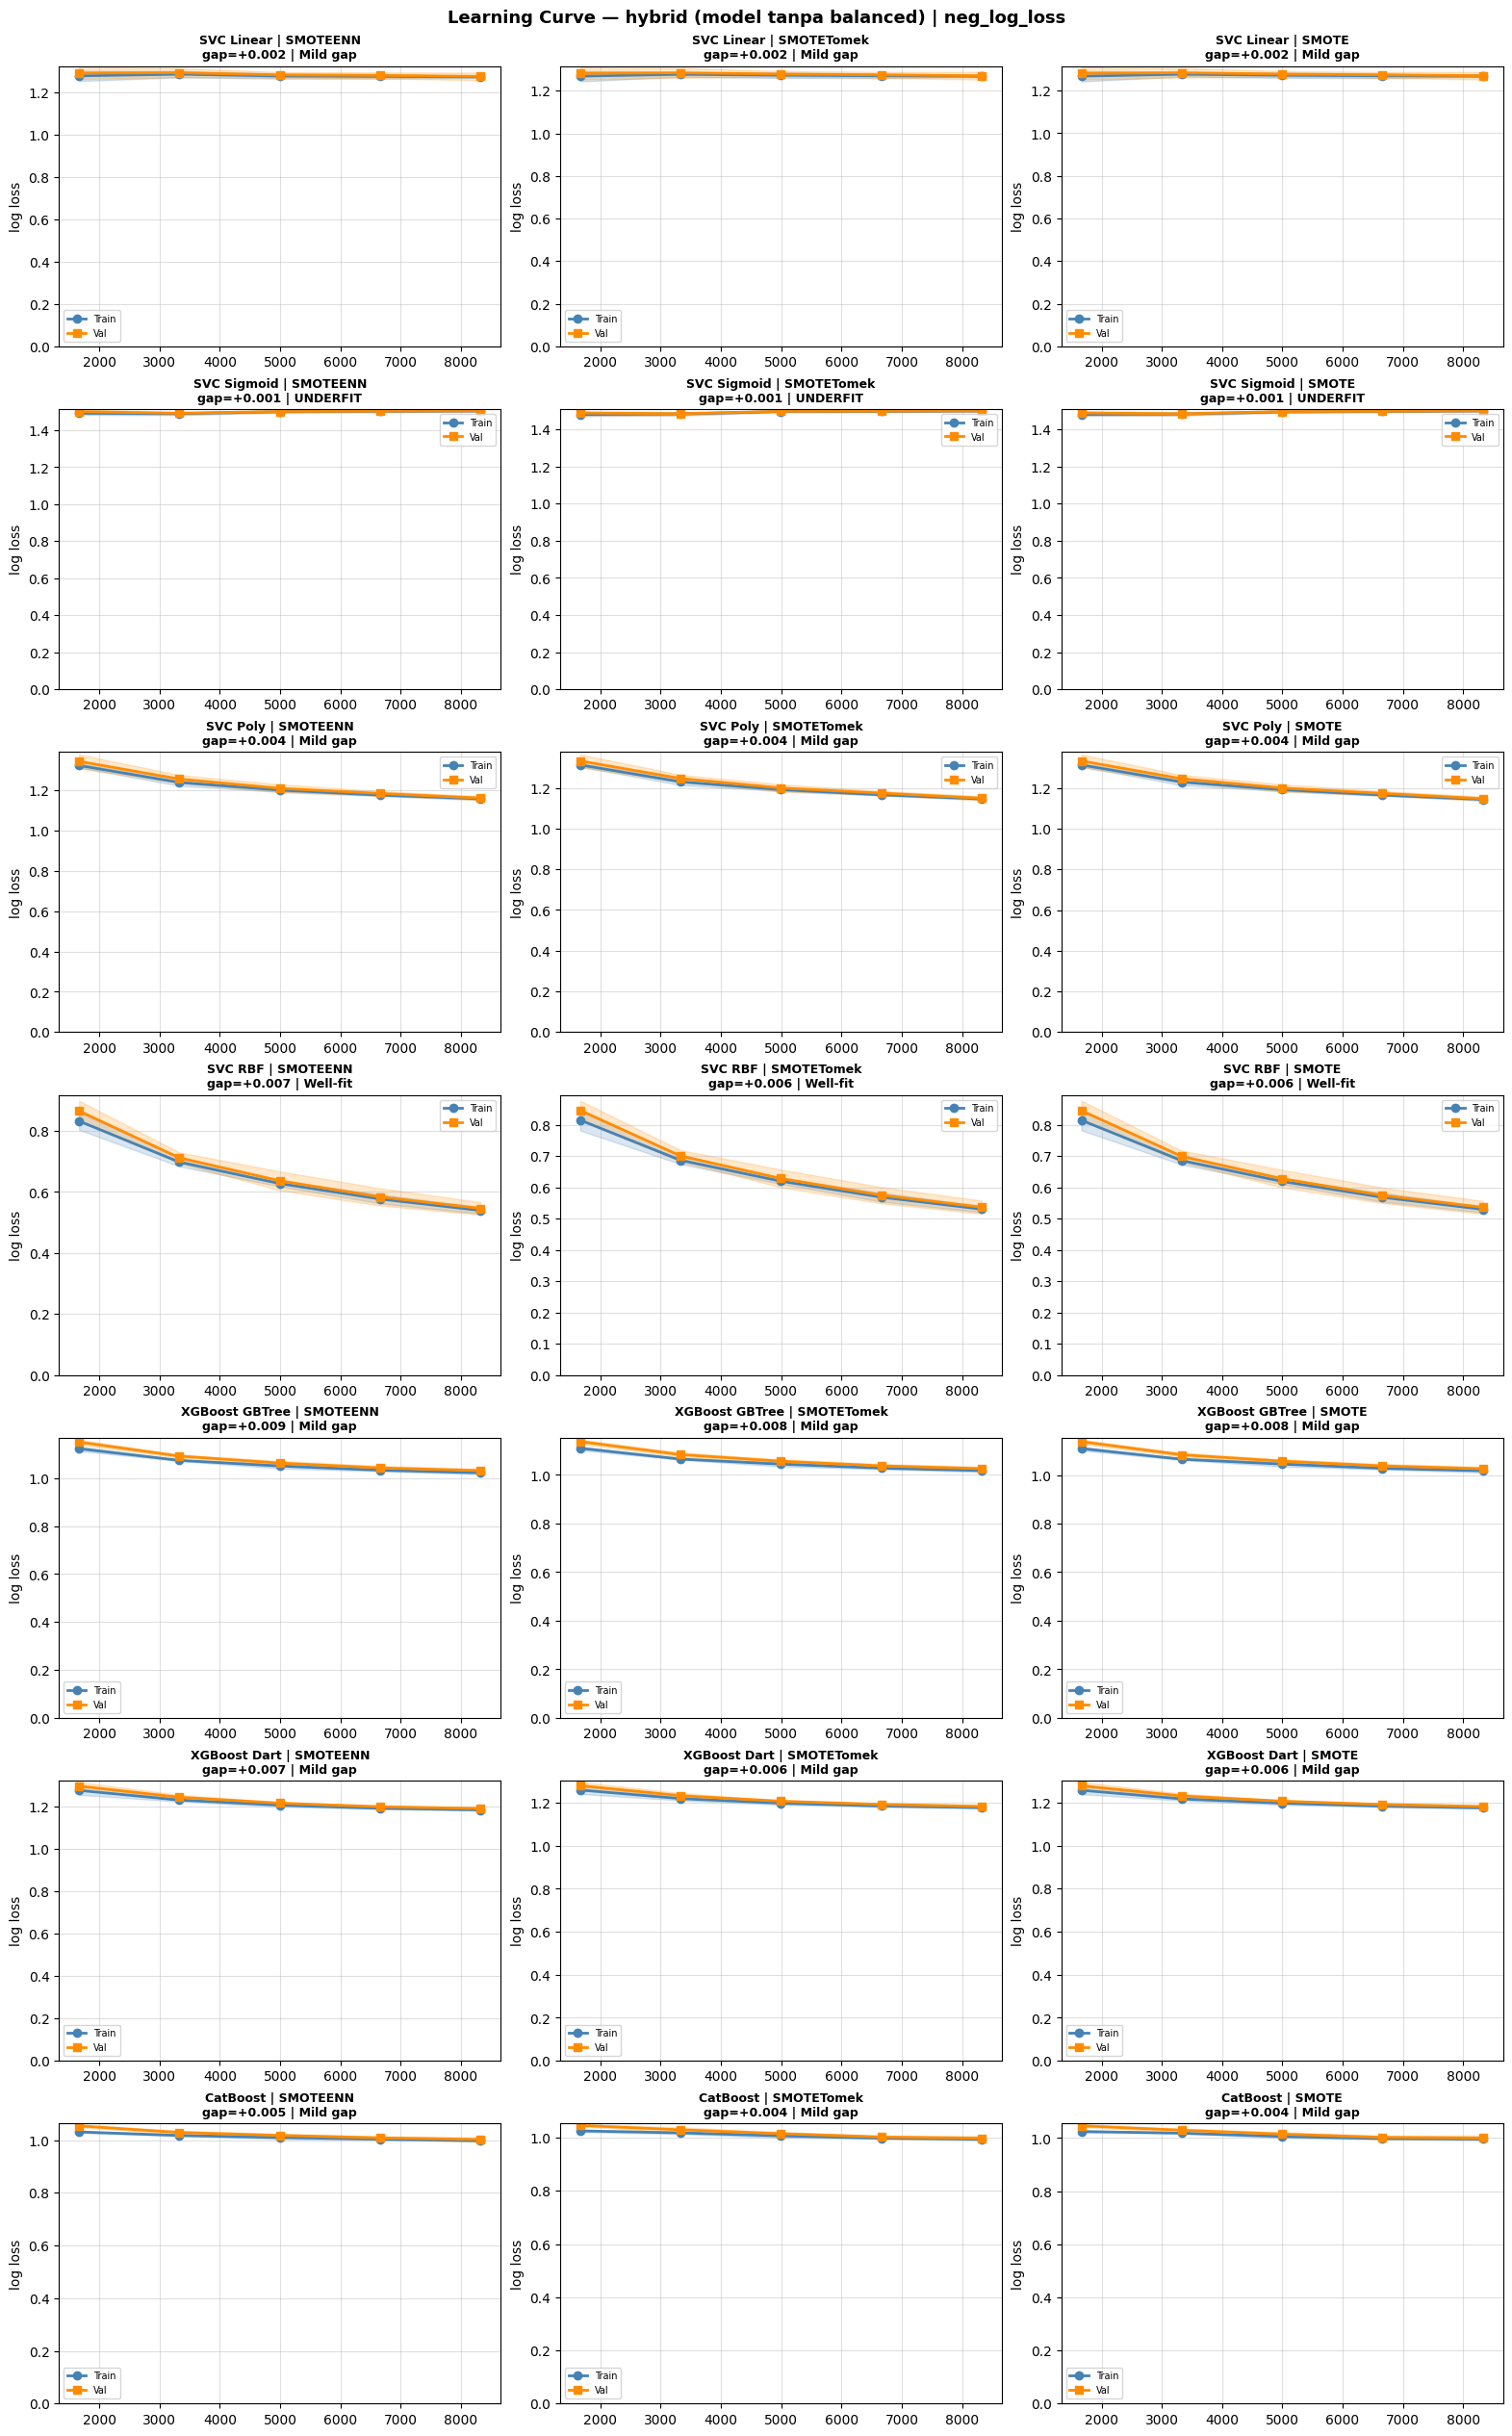

In [16]:
LC_BASELINE = float(np.log(len(np.unique(y))))   # log loss tebakan-acak (ambang verdict)
nrows = len(MODELS); ncols = len(techs)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), constrained_layout=True)
axes = np.atleast_2d(axes)
for i, name in enumerate(MODELS):
    for j, tech in enumerate(techs):
        ax = axes[i, j]
        if (name, tech) not in lc:
            ax.axis('off'); continue
        ts, trm, trs, vam, vas = lc[(name, tech)]
        trm, vam = -trm, -vam   # neg_log_loss → log loss (positif; makin kecil makin baik)
        ax.plot(ts, trm, 'o-', color='steelblue', lw=2, label='Train')
        ax.fill_between(ts, trm - trs, trm + trs, alpha=0.2, color='steelblue')
        ax.plot(ts, vam, 's-', color='darkorange', lw=2, label='Val')
        ax.fill_between(ts, vam - vas, vam + vas, alpha=0.2, color='darkorange')
        gap = vam[-1] - trm[-1]   # val_loss − train_loss (>0 → overfit)
        v = ('OVERFIT' if gap > 0.15 * LC_BASELINE else 'UNDERFIT' if vam[-1] > 0.80 * LC_BASELINE
             else 'Well-fit' if gap < 0.05 * LC_BASELINE and vam[-1] < 0.40 * LC_BASELINE else 'Mild gap')
        ax.set_title(f'{name} | {tech}\ngap={gap:+.3f} | {v}', fontsize=9, fontweight='bold')
        ax.set_ylim(bottom=0); ax.set_ylabel('log loss'); ax.grid(True, alpha=0.4); ax.legend(fontsize=7)
fig.suptitle(f'Learning Curve — {STRATEGY} (model tanpa balanced) | {LC_SCORING}',
             fontsize=13, fontweight='bold')
fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_learning_curve.png'), dpi=110, bbox_inches='tight')
plt.show()

## 10. Kurva Seluruh Metrik Evaluasi (Train vs Val)

Learning curve untuk **semua** metrik sekaligus: **accuracy, precision, recall, f1 (macro)** dan **loss function (log loss)** terhadap ukuran data latih. Tiap (ukuran fold) di-*fit* sekali lalu kelima metrik dihitung bersama (lebih hemat daripada memanggil `learning_curve` per-metrik). Lingkup = teknik resampling (mode resample, classifier tanpa bobot), sama dengan Sel 9. Grid: baris = model, kolom = teknik.

In [17]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss)

# Pakai konfigurasi yg sama dgn Sel 9 (LC_TRAIN_SIZES, LC_CV, LC_STATE, techs).
CURVE_METRICS = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'log_loss']

def _full_proba(pipe, Xset, labels):
    """Selaraskan kolom predict_proba ke urutan `labels` (isi 0 utk kelas yg tak
    dilatih di subset), lalu normalisasi -> aman utk log_loss & subset kecil."""
    proba = np.asarray(pipe.predict_proba(Xset), dtype=float)
    idx = {c: k for k, c in enumerate(labels)}
    full = np.zeros((proba.shape[0], len(labels)))
    for k, c in enumerate(pipe.classes_):
        full[:, idx[c]] = proba[:, k]
    s = full.sum(1, keepdims=True); s[s == 0] = 1.0
    return full / s

def _score_all(y_true, y_pred, y_proba, labels):
    return {
        'accuracy':        accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred, average='macro', zero_division=0),
        'log_loss':        log_loss(y_true, y_proba, labels=labels),
    }

curves = {}   # (model, tech) -> metric -> (sizes, tr_mean, tr_std, va_mean, va_std)
skf_cv = StratifiedKFold(LC_CV, shuffle=True, random_state=LC_STATE)
nsz = len(LC_TRAIN_SIZES); min_n = len(np.unique(y))
for name in MODELS:
    for tech in techs:
        log(f'  > Kurva metrik: {name} | {tech} ...')
        tr = {m: [[] for _ in range(nsz)] for m in CURVE_METRICS}
        va = {m: [[] for _ in range(nsz)] for m in CURVE_METRICS}
        for tr_idx, va_idx in skf_cv.split(X, y):
            tr_idx = tr_idx.copy()
            np.random.RandomState(LC_STATE).shuffle(tr_idx)
            Xva, yva = X.iloc[va_idx], y[va_idx]
            for k, frac in enumerate(LC_TRAIN_SIZES):
                sub = tr_idx[:max(min_n, int(round(frac * len(tr_idx))))]
                Xsub, ysub = X.iloc[sub], y[sub]
                try:
                    pipe = make_resample_pipeline(
                        name, BEST_PARAMS[name], RESAMPLERS[tech], n_optimal,
                        xgb_device=XGB_DEVICE, cat_task_type=CAT_TASK_TYPE, probability=True)
                    pipe.fit(Xsub, ysub)
                    for Xset, yset, store in ((Xsub, ysub, tr), (Xva, yva, va)):
                        yp = np.ravel(pipe.predict(Xset))
                        sc = _score_all(yset, yp, _full_proba(pipe, Xset, labels), labels)
                        for m in CURVE_METRICS:
                            store[m][k].append(sc[m])
                except Exception as e:
                    for m in CURVE_METRICS:
                        tr[m][k].append(np.nan); va[m][k].append(np.nan)
                    log(f'    skip [{name}|{tech}|frac={frac:.2f}] -> {type(e).__name__}: {e}')
        curves[(name, tech)] = {
            m: (LC_TRAIN_SIZES,
                np.array([np.nanmean(tr[m][k]) for k in range(nsz)]),
                np.array([np.nanstd(tr[m][k])  for k in range(nsz)]),
                np.array([np.nanmean(va[m][k]) for k in range(nsz)]),
                np.array([np.nanstd(va[m][k])  for k in range(nsz)]))
            for m in CURVE_METRICS}
log(f'Kurva metrik selesai: {len(curves)} (model x teknik).')

  > Kurva metrik: SVC Linear | SMOTEENN ...
  > Kurva metrik: SVC Linear | SMOTETomek ...
  > Kurva metrik: SVC Linear | SMOTE ...
  > Kurva metrik: SVC Sigmoid | SMOTEENN ...
  > Kurva metrik: SVC Sigmoid | SMOTETomek ...
  > Kurva metrik: SVC Sigmoid | SMOTE ...
  > Kurva metrik: SVC Poly | SMOTEENN ...
  > Kurva metrik: SVC Poly | SMOTETomek ...
  > Kurva metrik: SVC Poly | SMOTE ...
  > Kurva metrik: SVC RBF | SMOTEENN ...
  > Kurva metrik: SVC RBF | SMOTETomek ...
  > Kurva metrik: SVC RBF | SMOTE ...
  > Kurva metrik: XGBoost GBTree | SMOTEENN ...
  > Kurva metrik: XGBoost GBTree | SMOTETomek ...
  > Kurva metrik: XGBoost GBTree | SMOTE ...
  > Kurva metrik: XGBoost Dart | SMOTEENN ...
  > Kurva metrik: XGBoost Dart | SMOTETomek ...
  > Kurva metrik: XGBoost Dart | SMOTE ...
  > Kurva metrik: CatBoost | SMOTEENN ...
  > Kurva metrik: CatBoost | SMOTETomek ...
  > Kurva metrik: CatBoost | SMOTE ...
Kurva metrik selesai: 21 (model x teknik).


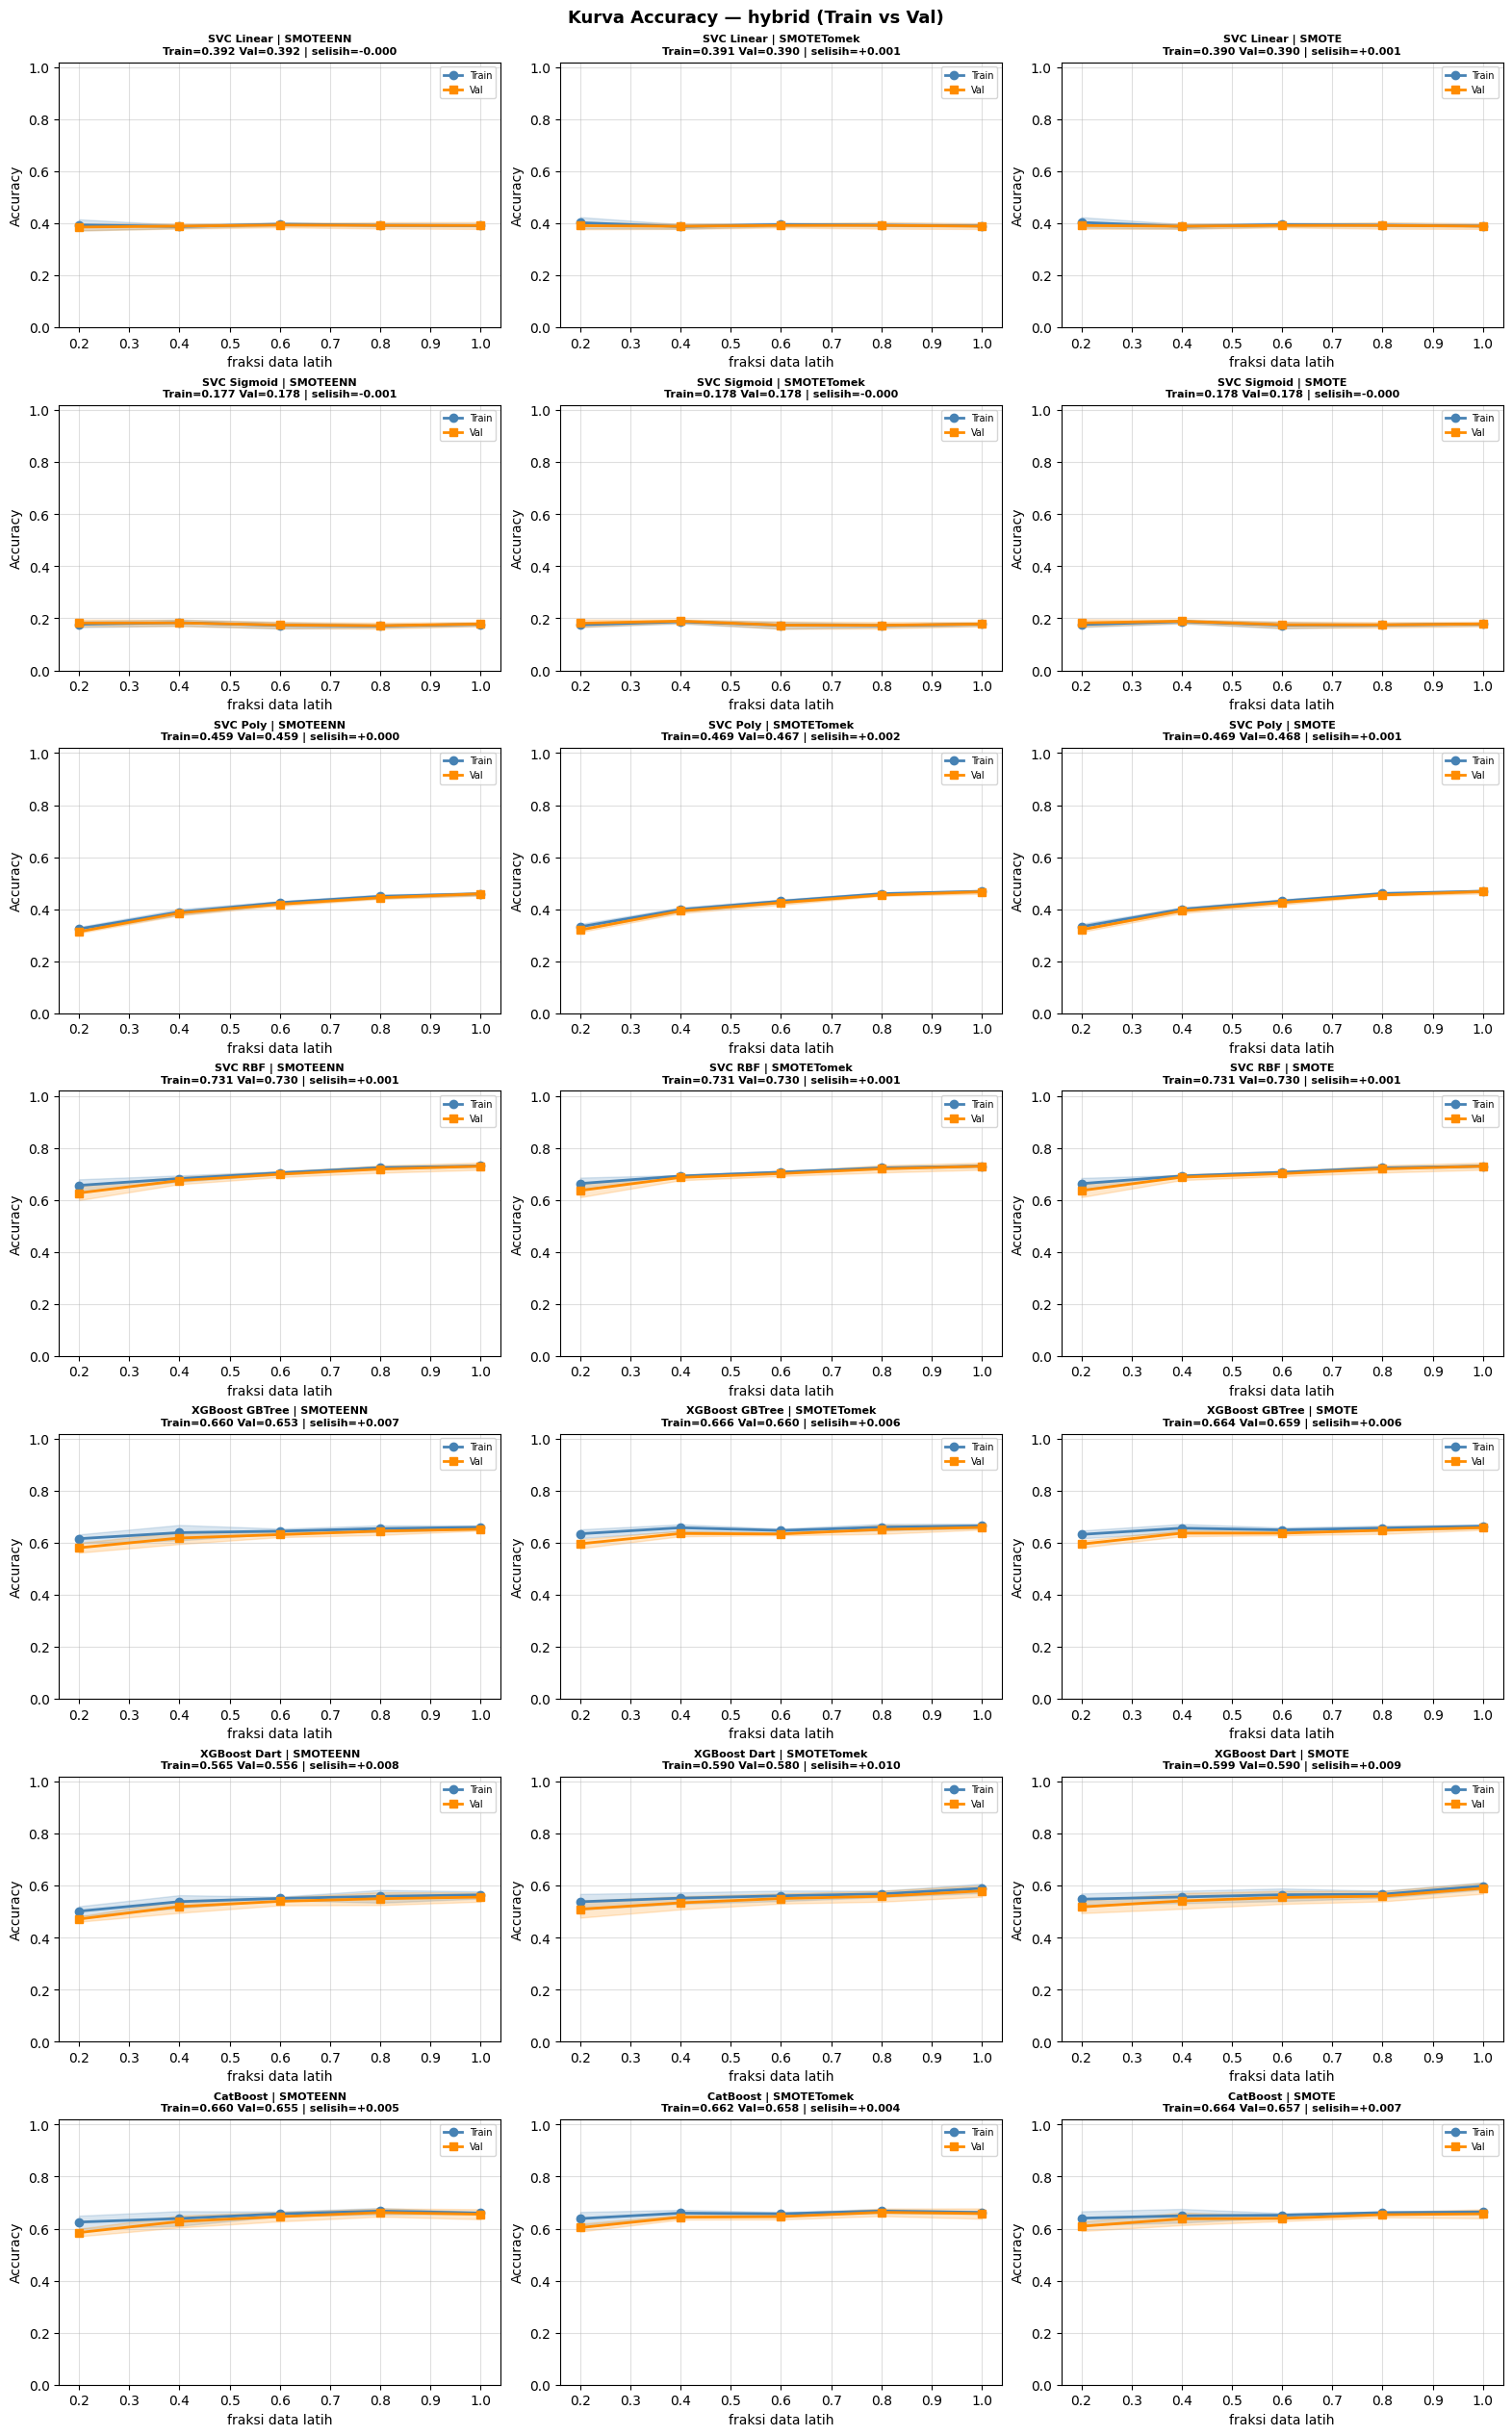

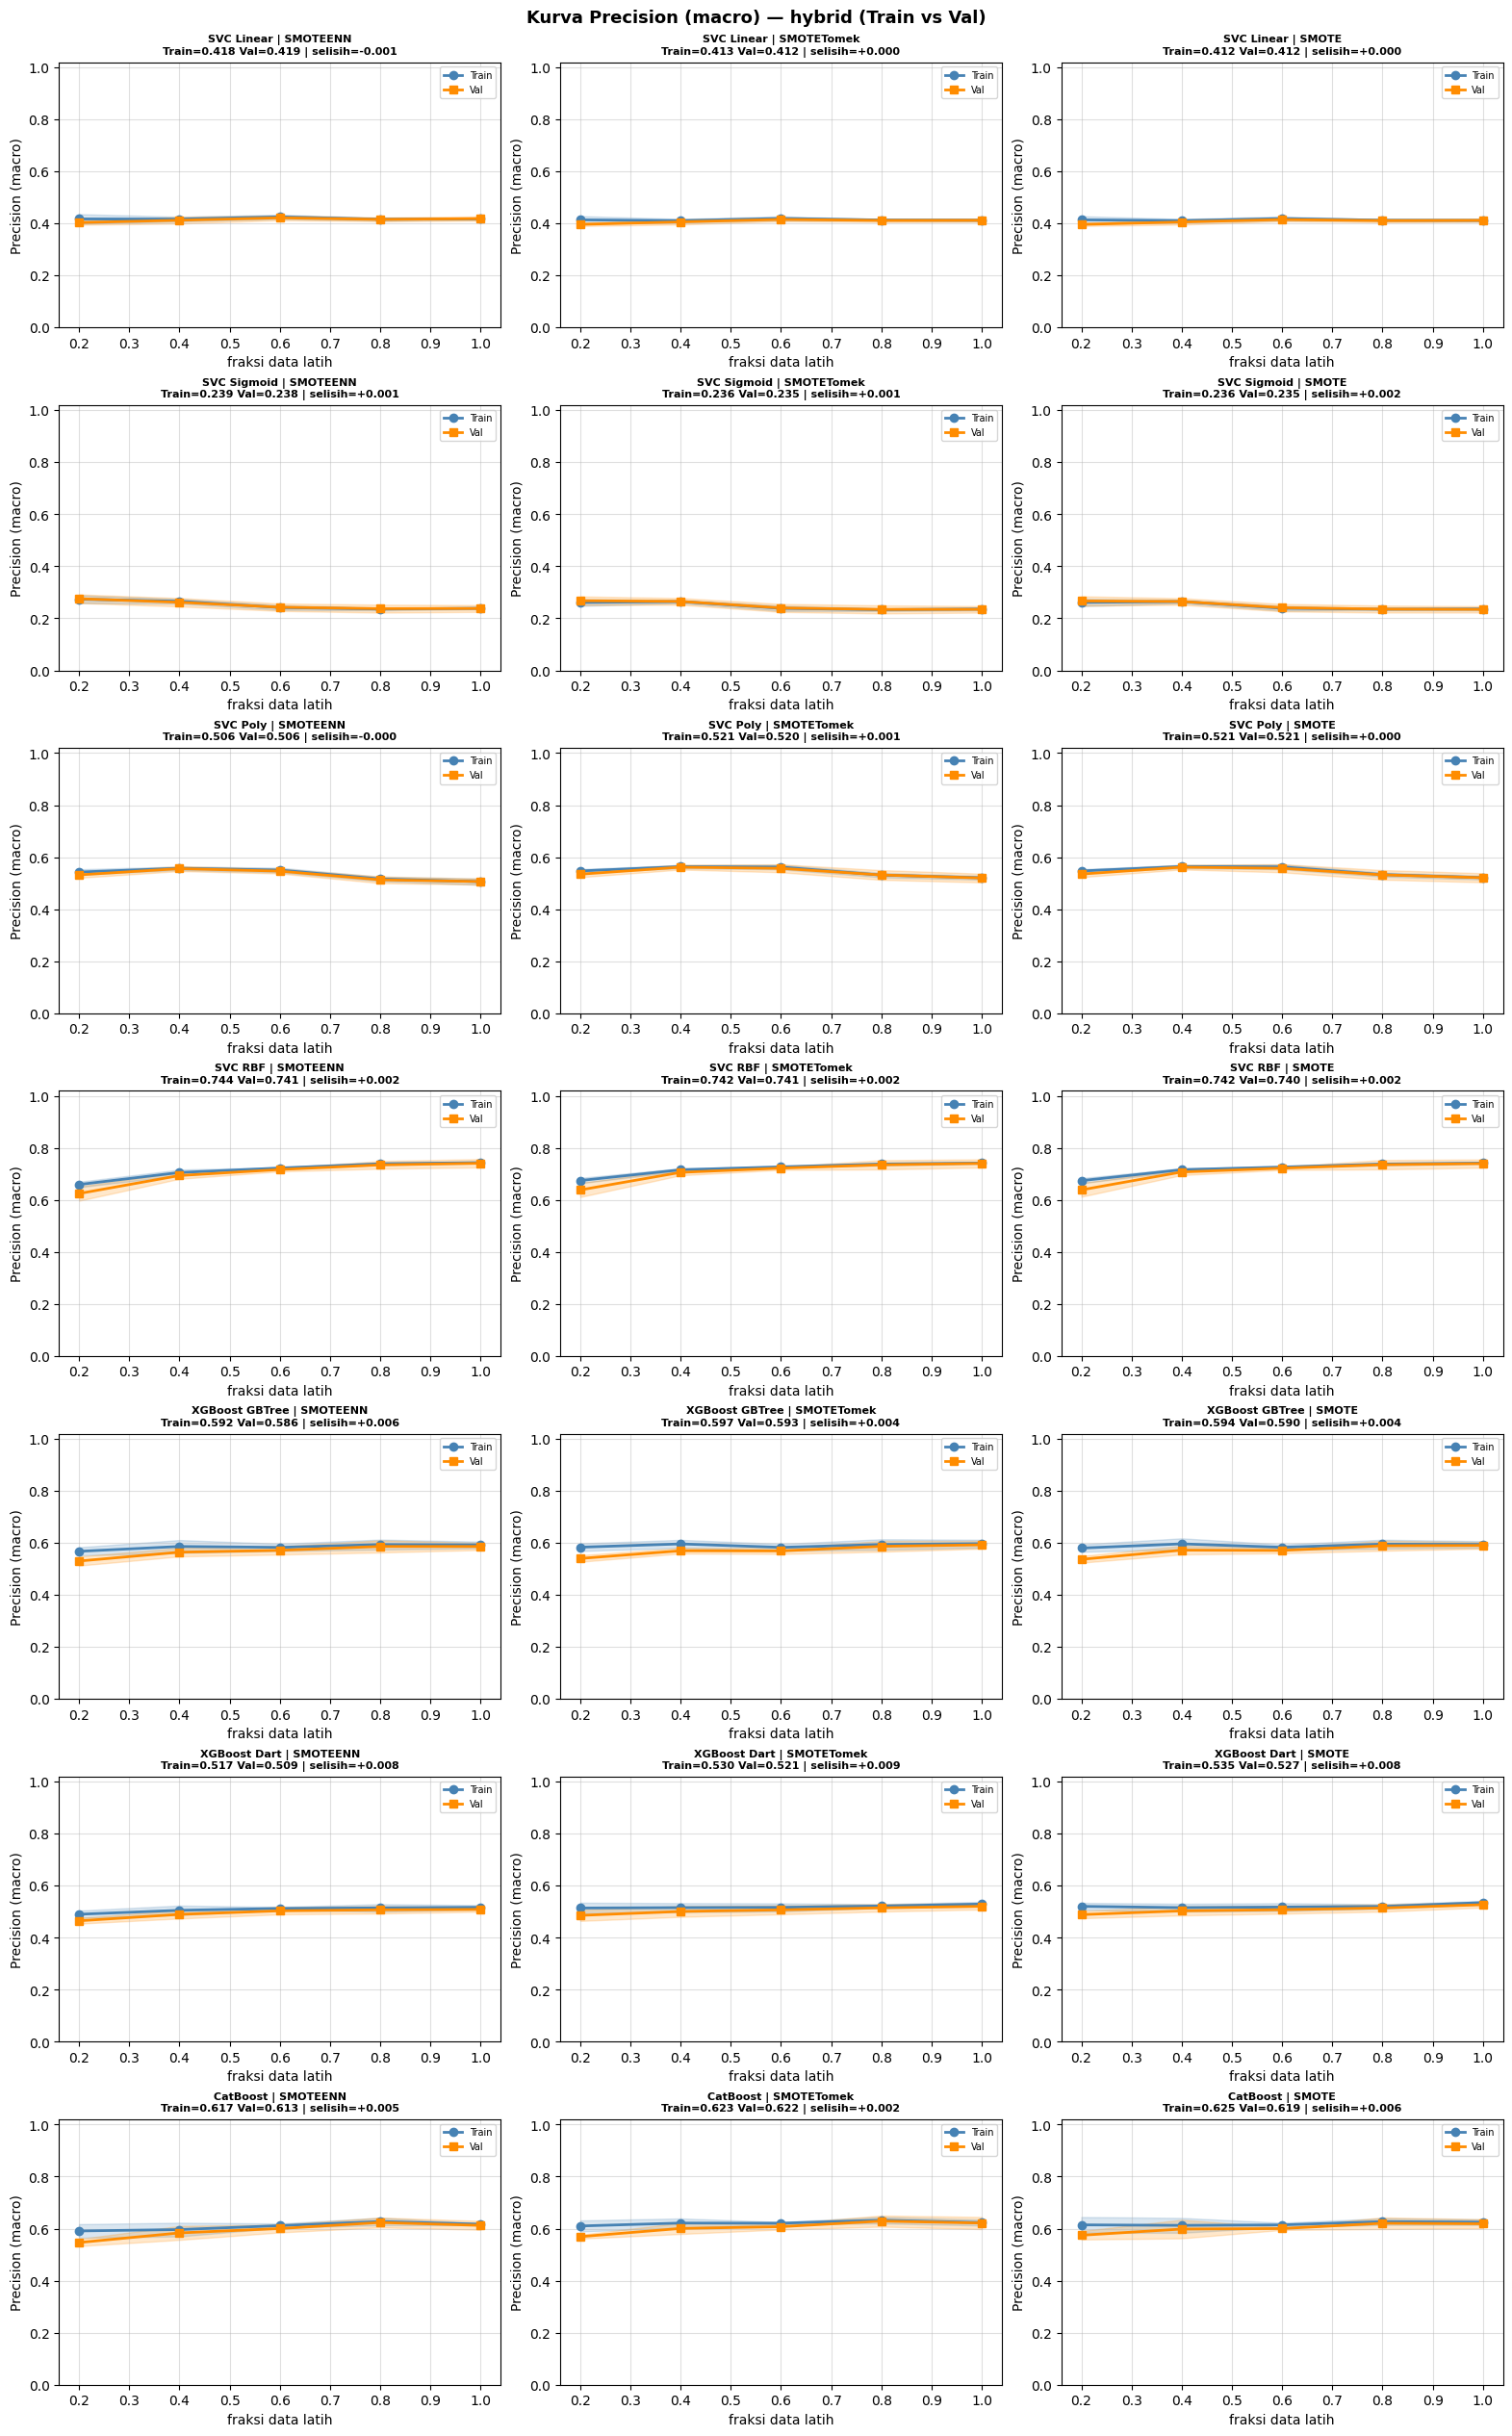

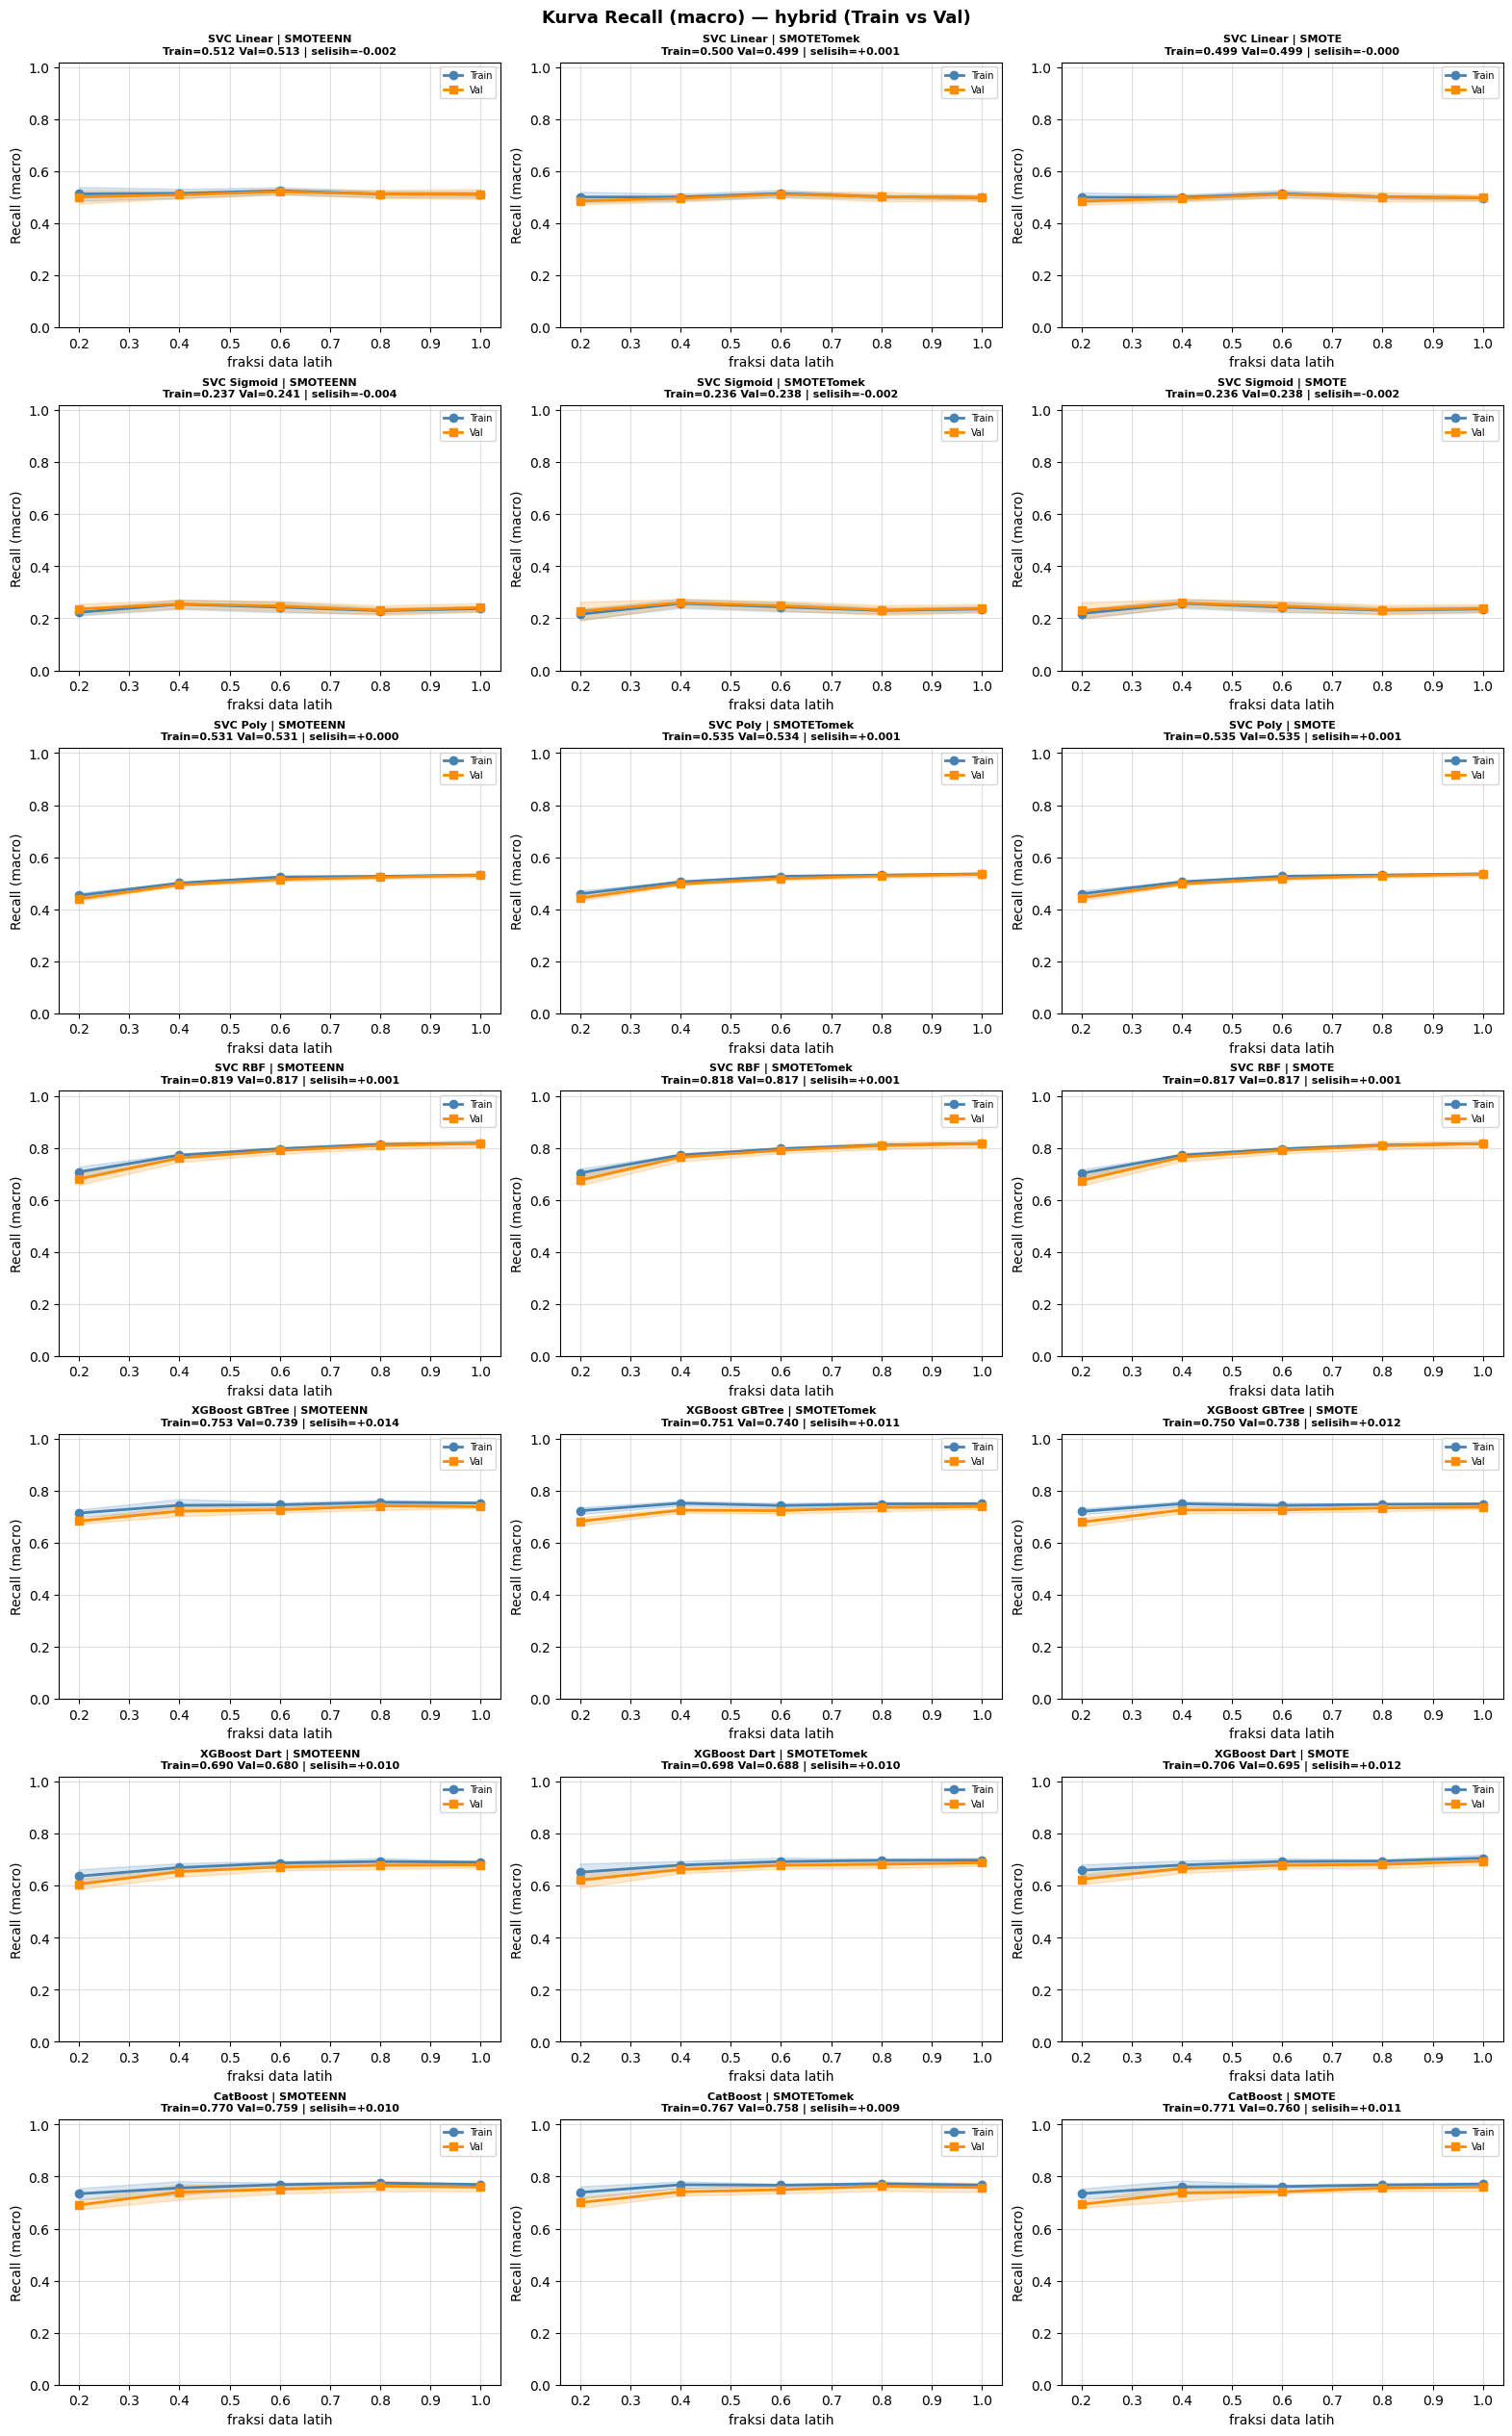

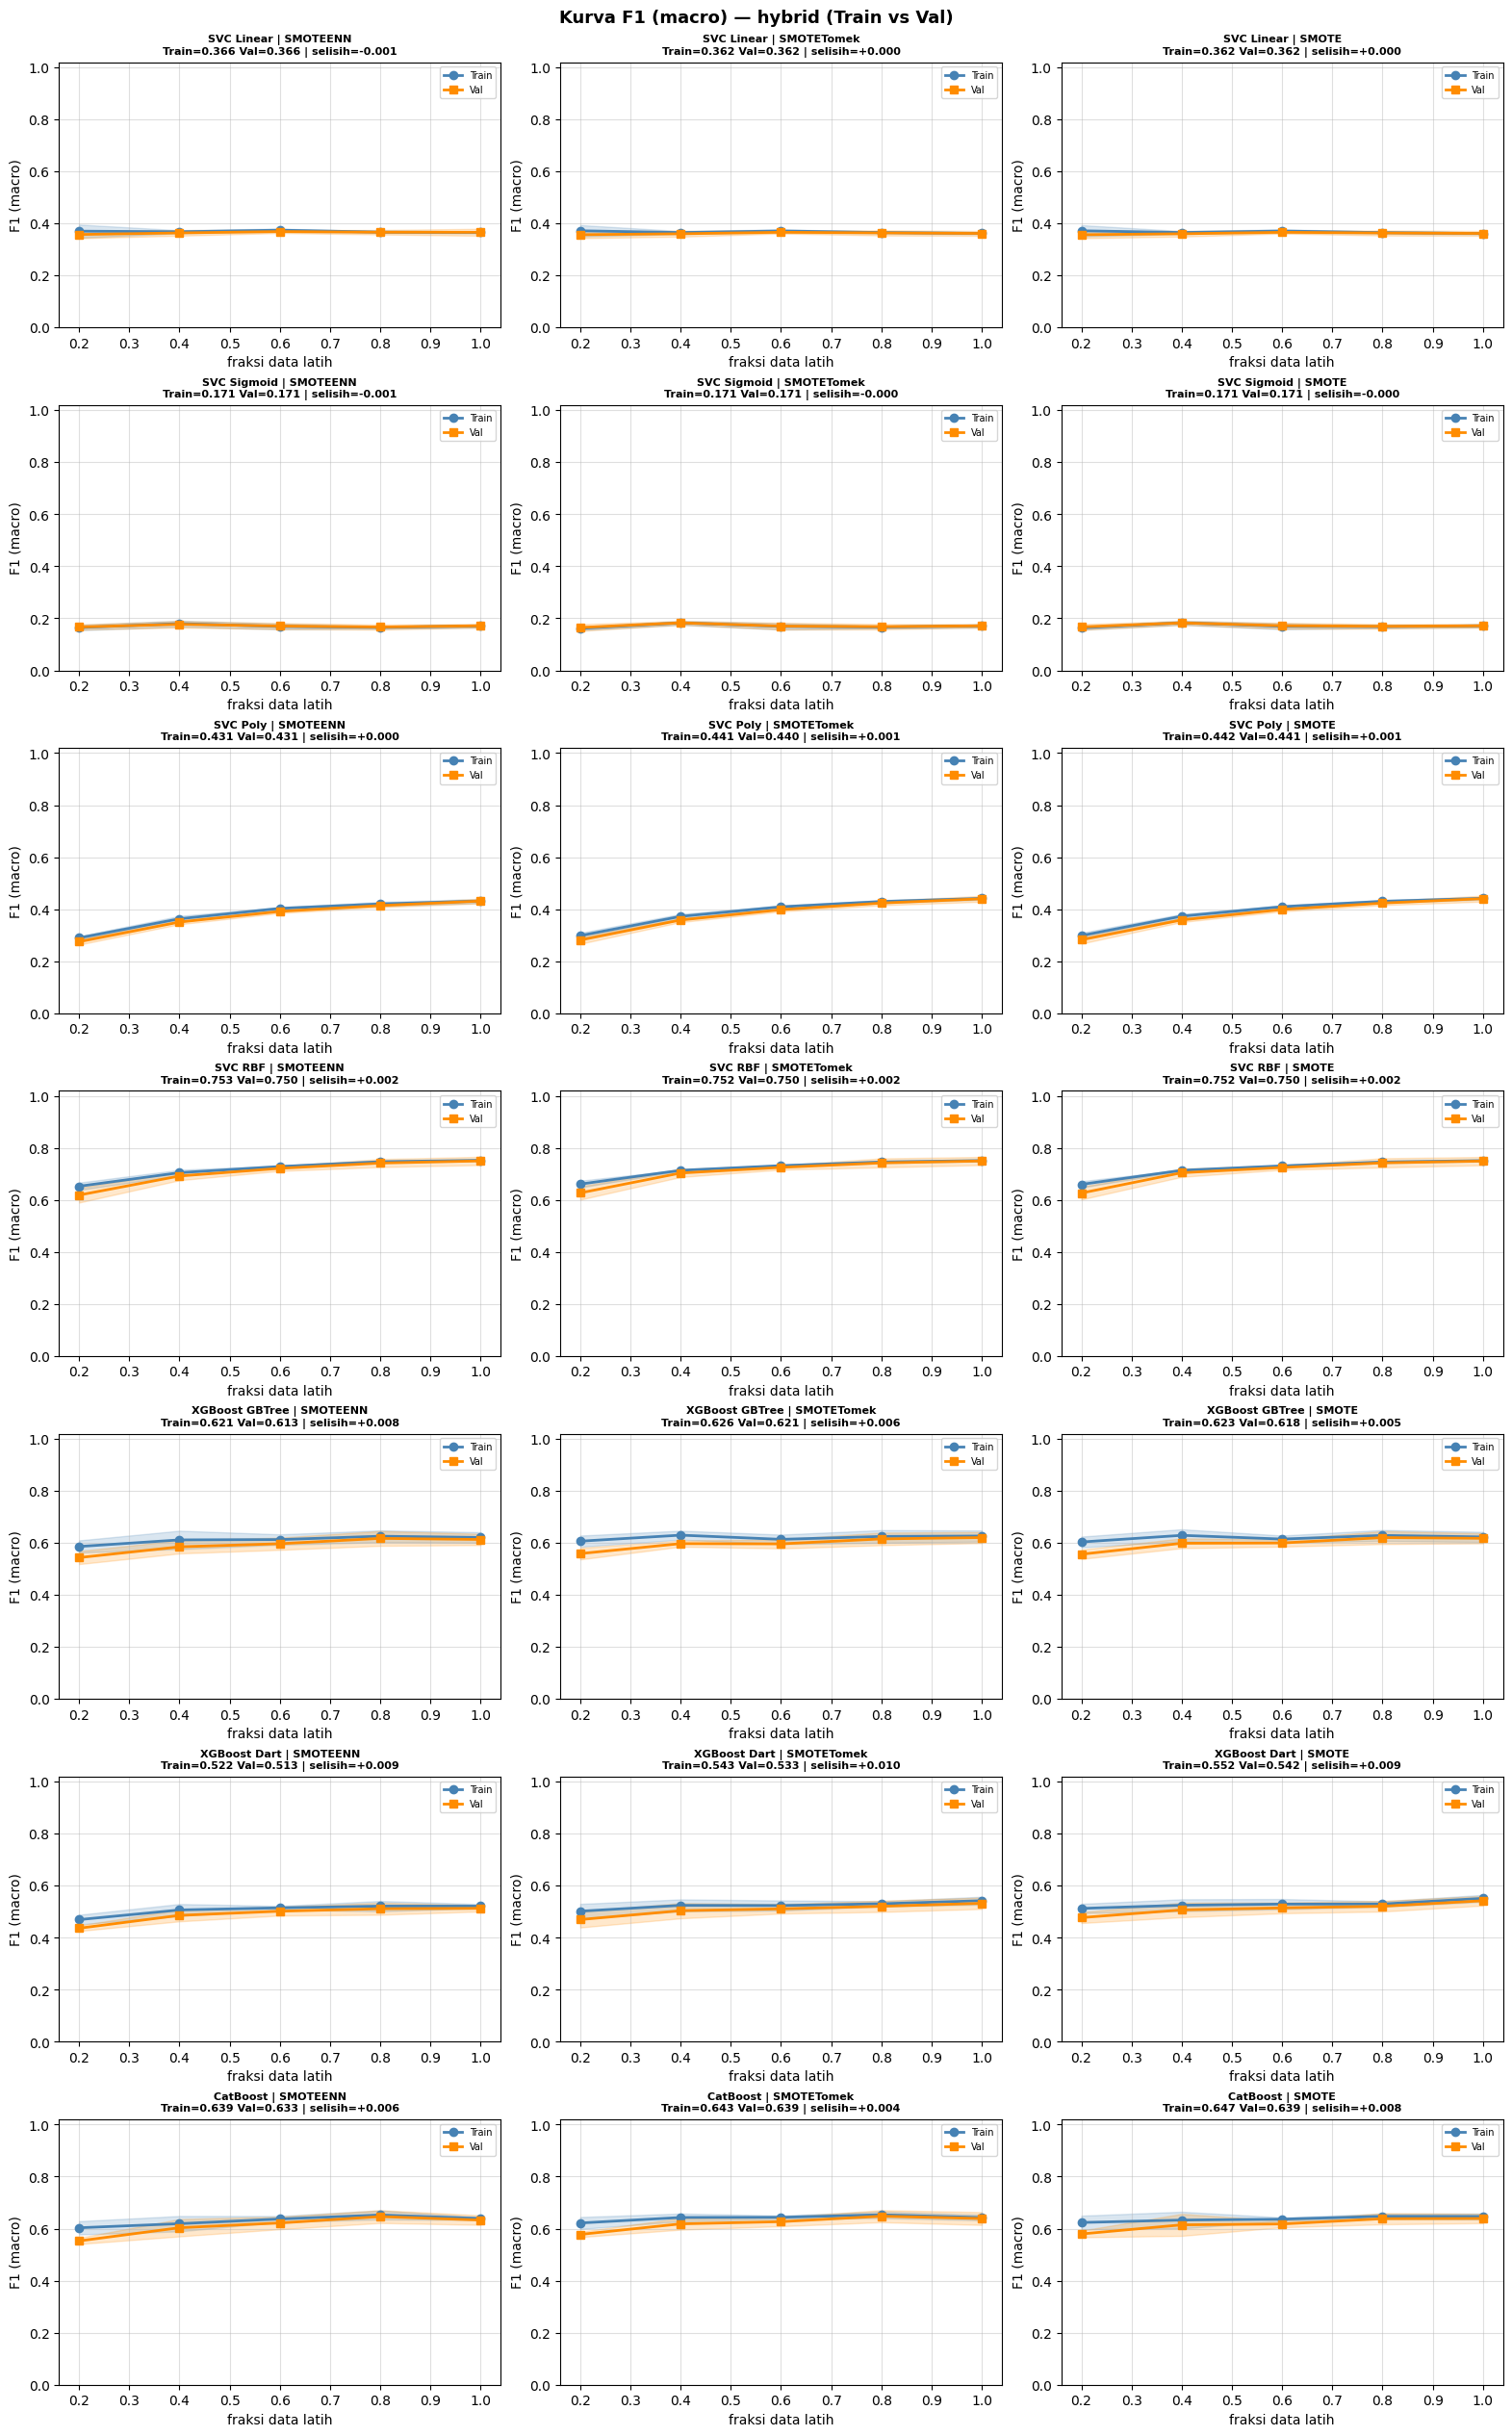

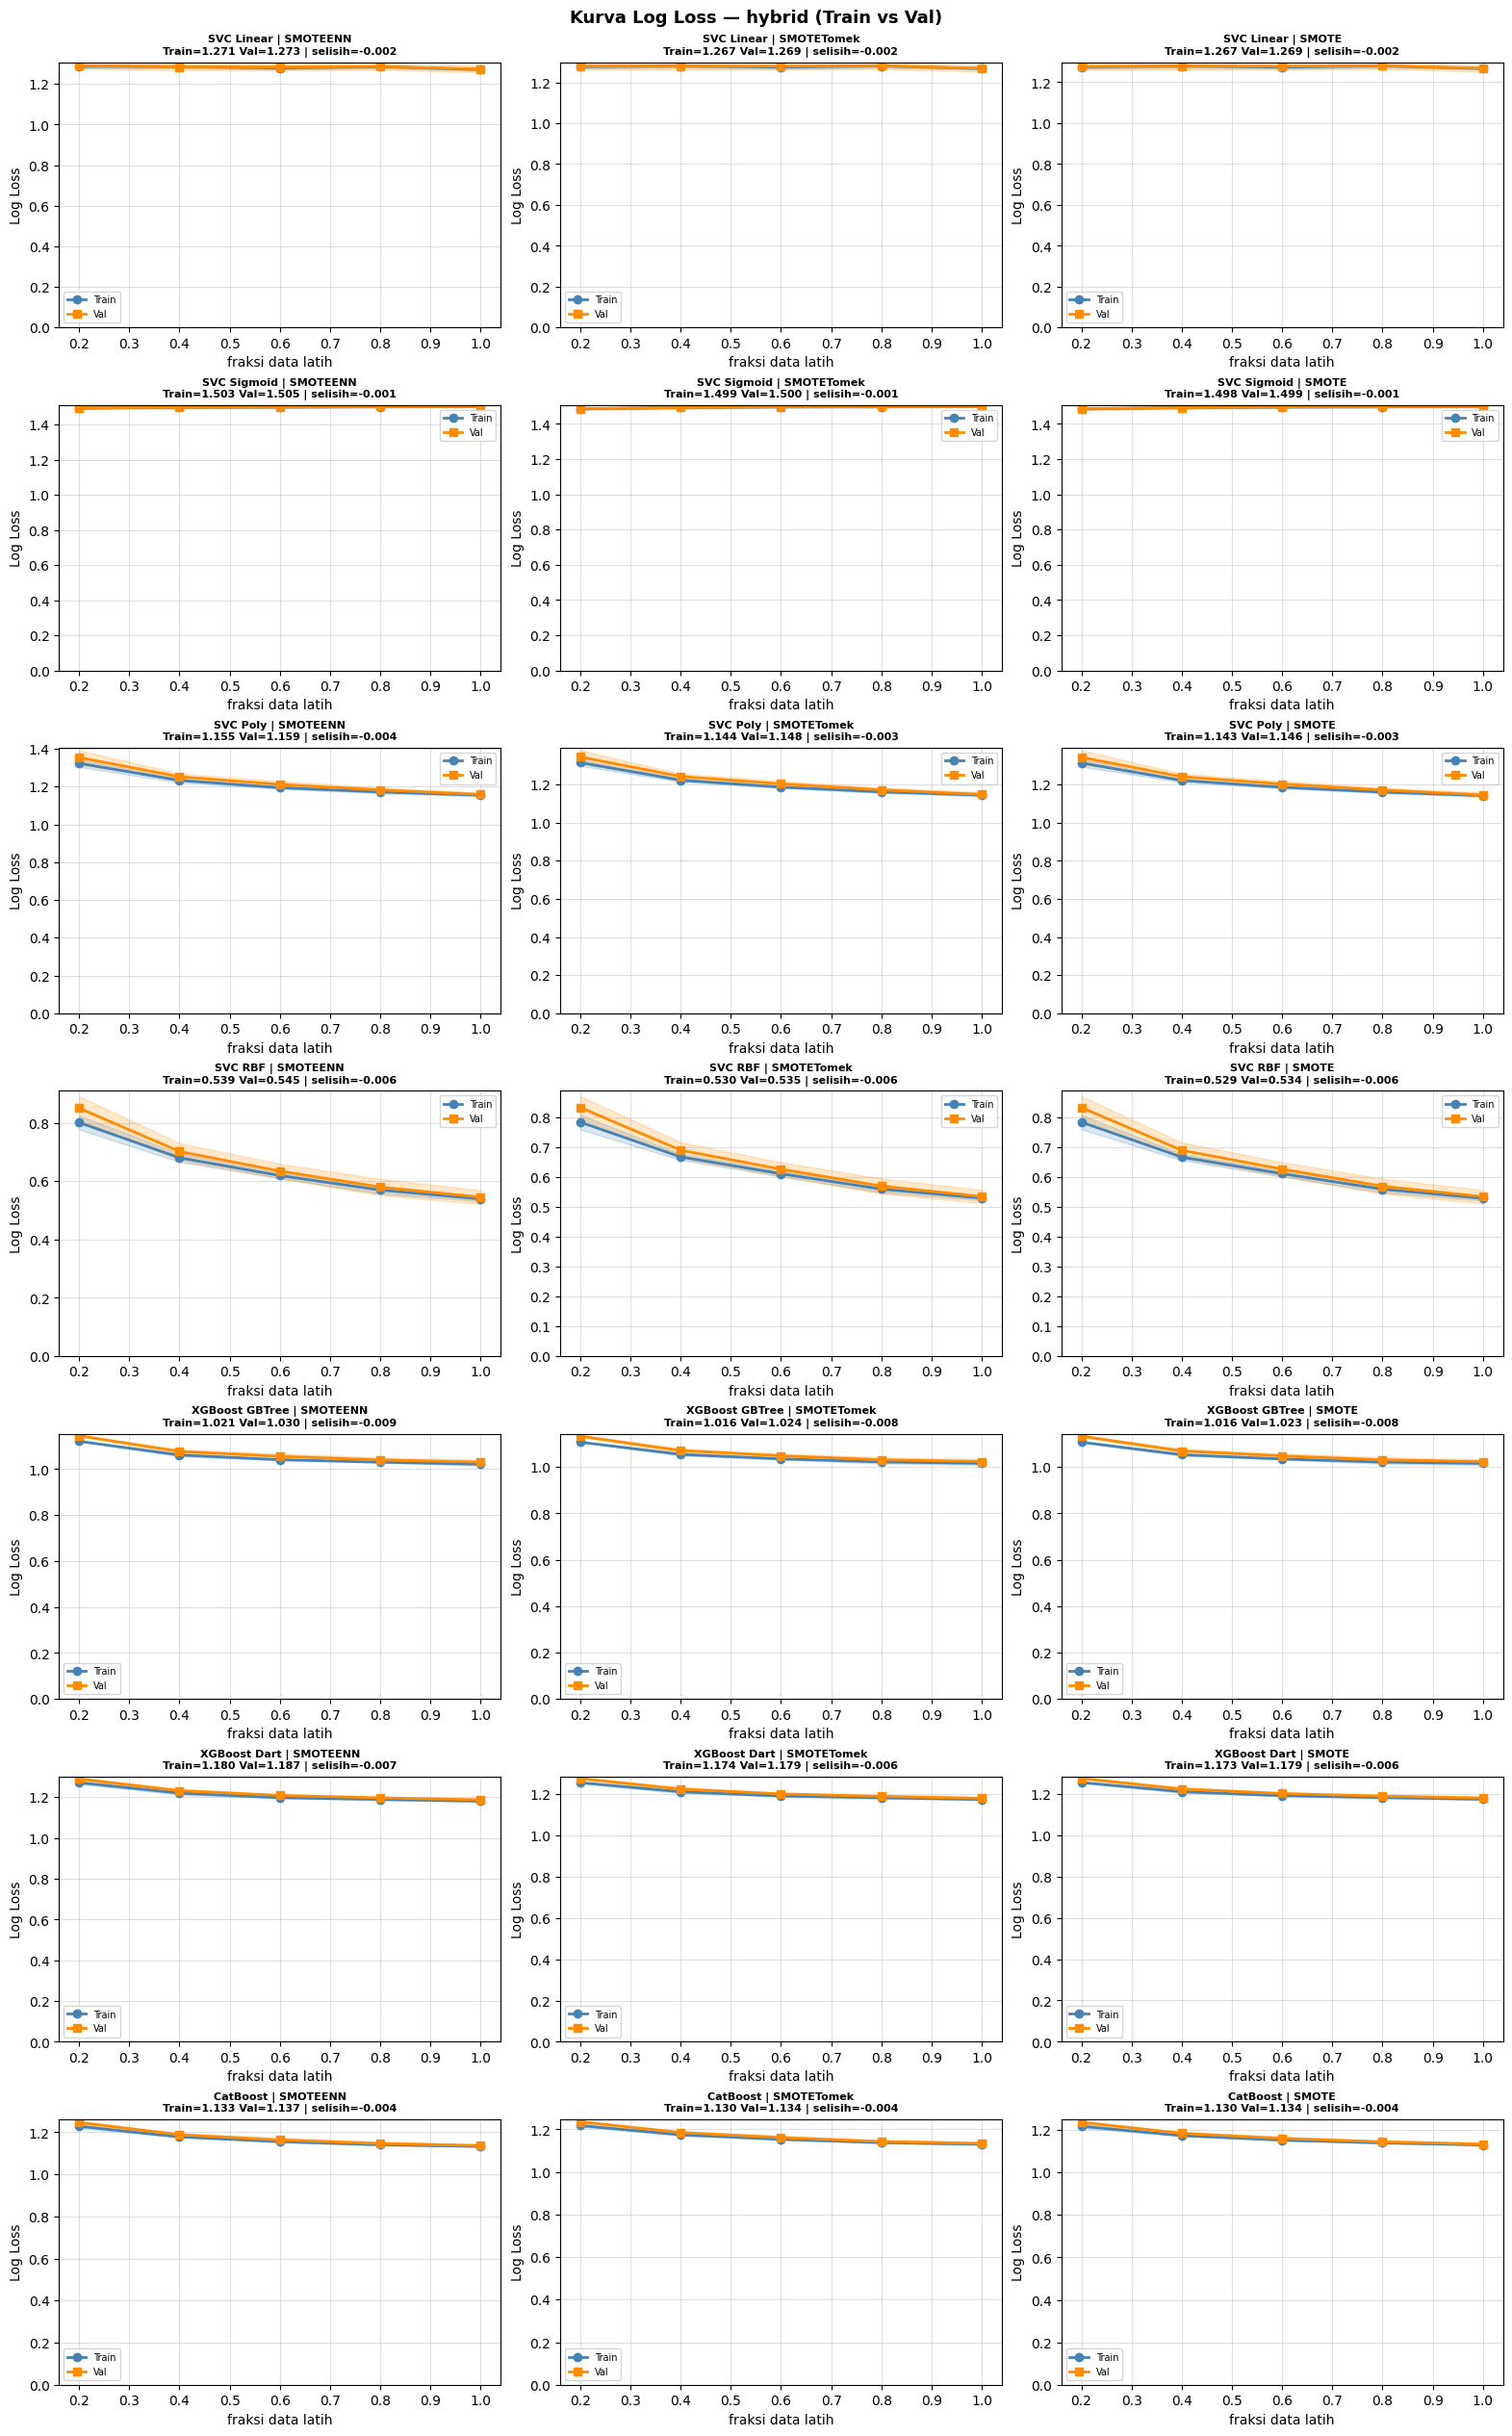

In [18]:
METRIC_TITLES = {'accuracy': 'Accuracy', 'precision_macro': 'Precision (macro)',
                 'recall_macro': 'Recall (macro)', 'f1_macro': 'F1 (macro)',
                 'log_loss': 'Log Loss'}
nrows, ncols = len(MODELS), len(techs)
for metric in CURVE_METRICS:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows),
                             constrained_layout=True)
    axes = np.atleast_2d(axes)
    for i, name in enumerate(MODELS):
        for j, tech in enumerate(techs):
            ax = axes[i, j]
            if (name, tech) not in curves:
                ax.axis('off'); continue
            ts, trm, trs, vam, vas = curves[(name, tech)][metric]
            ax.plot(ts, trm, 'o-', color='steelblue', lw=2, label='Train')
            ax.fill_between(ts, trm - trs, trm + trs, alpha=0.2, color='steelblue')
            ax.plot(ts, vam, 's-', color='darkorange', lw=2, label='Val')
            ax.fill_between(ts, vam - vas, vam + vas, alpha=0.2, color='darkorange')
            # selisih train vs val di fraksi data latih terbesar
            gap = trm[-1] - vam[-1]
            ax.set_title(f'{name} | {tech}\nTrain={trm[-1]:.3f} Val={vam[-1]:.3f} | selisih={gap:+.3f}',
                         fontsize=8, fontweight='bold')
            ax.set_xlabel('fraksi data latih'); ax.set_ylabel(METRIC_TITLES[metric])
            if metric == 'log_loss':
                ax.set_ylim(bottom=0)
            else:
                ax.set_ylim(0, 1.02)
            ax.grid(True, alpha=0.4); ax.legend(fontsize=7)
    fig.suptitle(f'Kurva {METRIC_TITLES[metric]} — {STRATEGY} (Train vs Val)',
                 fontsize=13, fontweight='bold')
    fig.savefig(os.path.join(OUT_DIR, f'{STRATEGY}_curve_{metric}.png'),
                dpi=110, bbox_inches='tight')
    plt.show()

### Selisih (gap) Train vs Val — tabel terpisah per metrik

Satu tabel untuk tiap metrik (**Accuracy, Precision, Recall, F1**, dan Log Loss), berisi nilai `Train`, `Val`, dan `Selisih (Train-Val)` di fraksi data latih terbesar untuk tiap (model × teknik). Kolom `overfit_gap` menyeragamkan arah: **>0 = indikasi overfit** (skor = Train−Val; `log_loss` = Val−Train, karena loss makin kecil makin baik). Makin besar `overfit_gap`, makin lebar jurang train↔val.

In [19]:
# -- Tabel selisih (gap) Train vs Val, DIPISAH per metrik (fraksi data latih terbesar) --
gap_tables = {}
for metric in CURVE_METRICS:
    rows = []
    for (name, tech), mdict in curves.items():
        ts, trm, trs, vam, vas = mdict[metric]
        train_f, val_f = float(trm[-1]), float(vam[-1])
        train_s, val_s = float(trs[-1]), float(vas[-1])   # std antar-fold di fraksi terbesar
        selisih = train_f - val_f
        overfit_gap = (val_f - train_f) if metric == 'log_loss' else (train_f - val_f)
        rows.append({'Model': name, 'Teknik': tech,
                     'Train': train_f, 'Train_std': train_s,
                     'Val': val_f, 'Val_std': val_s,
                     'Selisih (Train-Val)': selisih, 'overfit_gap': overfit_gap})
    df = pd.DataFrame(rows)
    gap_tables[metric] = df
    df.to_csv(os.path.join(OUT_DIR, f'{STRATEGY}_gap_{metric}.csv'), index=False)
    log(f'[{METRIC_TITLES[metric]}] selisih train-val -> {STRATEGY}_gap_{metric}.csv')

# Tampilkan satu tabel per metrik: Train & Val sbg 'mean ± std' (overfit_gap diwarnai).
for metric in CURVE_METRICS:
    df = gap_tables[metric]
    disp = pd.DataFrame({'Model': df['Model'], 'Teknik': df['Teknik']})
    disp['Train'] = [f'{m:.4f} ± {s:.4f}' for m, s in zip(df['Train'], df['Train_std'])]
    disp['Val']   = [f'{m:.4f} ± {s:.4f}' for m, s in zip(df['Val'], df['Val_std'])]
    disp['Selisih (Train-Val)'] = df['Selisih (Train-Val)']
    disp['overfit_gap'] = df['overfit_gap']
    print('=' * 60)
    print(f'Metrik: {METRIC_TITLES[metric]}')
    display(disp.style.format({'Selisih (Train-Val)': '{:.4f}', 'overfit_gap': '{:.4f}'})
            .background_gradient(cmap='Reds', subset=['overfit_gap']))

[Accuracy] selisih train-val -> hybrid_gap_accuracy.csv
[Precision (macro)] selisih train-val -> hybrid_gap_precision_macro.csv
[Recall (macro)] selisih train-val -> hybrid_gap_recall_macro.csv
[F1 (macro)] selisih train-val -> hybrid_gap_f1_macro.csv
[Log Loss] selisih train-val -> hybrid_gap_log_loss.csv
Metrik: Accuracy


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTEENN,0.3921 ± 0.0032,0.3922 ± 0.0133,-0.0001,-0.0001
1,SVC Linear,SMOTETomek,0.3906 ± 0.0034,0.3897 ± 0.0110,0.0009,0.0009
2,SVC Linear,SMOTE,0.3903 ± 0.0032,0.3898 ± 0.0107,0.0006,0.0006
3,SVC Sigmoid,SMOTEENN,0.1774 ± 0.0062,0.1782 ± 0.0084,-0.0008,-0.0008
4,SVC Sigmoid,SMOTETomek,0.1779 ± 0.0065,0.1781 ± 0.0084,-0.0002,-0.0002
5,SVC Sigmoid,SMOTE,0.1783 ± 0.0062,0.1784 ± 0.0085,-0.0001,-0.0001
6,SVC Poly,SMOTEENN,0.4592 ± 0.0061,0.4591 ± 0.0070,0.0001,0.0001
7,SVC Poly,SMOTETomek,0.4688 ± 0.0039,0.4669 ± 0.0078,0.0019,0.0019
8,SVC Poly,SMOTE,0.4691 ± 0.0039,0.4677 ± 0.0077,0.0015,0.0015
9,SVC RBF,SMOTEENN,0.7309 ± 0.0037,0.7300 ± 0.0139,0.0008,0.0008


Metrik: Precision (macro)


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTEENN,0.4178 ± 0.0037,0.4187 ± 0.0085,-0.0008,-0.0008
1,SVC Linear,SMOTETomek,0.4125 ± 0.0038,0.4122 ± 0.0063,0.0003,0.0003
2,SVC Linear,SMOTE,0.4120 ± 0.0039,0.4119 ± 0.0059,0.0000,0.0000
3,SVC Sigmoid,SMOTEENN,0.2388 ± 0.0032,0.2381 ± 0.0132,0.0007,0.0007
4,SVC Sigmoid,SMOTETomek,0.2360 ± 0.0050,0.2347 ± 0.0126,0.0013,0.0013
5,SVC Sigmoid,SMOTE,0.2361 ± 0.0051,0.2345 ± 0.0123,0.0016,0.0016
6,SVC Poly,SMOTEENN,0.5059 ± 0.0120,0.5062 ± 0.0118,-0.0004,-0.0004
7,SVC Poly,SMOTETomek,0.5207 ± 0.0074,0.5198 ± 0.0167,0.0009,0.0009
8,SVC Poly,SMOTE,0.5213 ± 0.0076,0.5209 ± 0.0174,0.0004,0.0004
9,SVC RBF,SMOTEENN,0.7439 ± 0.0024,0.7414 ± 0.0160,0.0025,0.0025


Metrik: Recall (macro)


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTEENN,0.5116 ± 0.0110,0.5132 ± 0.0189,-0.0016,-0.0016
1,SVC Linear,SMOTETomek,0.4996 ± 0.0086,0.4990 ± 0.0117,0.0005,0.0005
2,SVC Linear,SMOTE,0.4986 ± 0.0093,0.4987 ± 0.0119,-0.0001,-0.0001
3,SVC Sigmoid,SMOTEENN,0.2373 ± 0.0100,0.2415 ± 0.0170,-0.0041,-0.0041
4,SVC Sigmoid,SMOTETomek,0.2357 ± 0.0111,0.2381 ± 0.0163,-0.0024,-0.0024
5,SVC Sigmoid,SMOTE,0.2358 ± 0.0110,0.2382 ± 0.0162,-0.0024,-0.0024
6,SVC Poly,SMOTEENN,0.5313 ± 0.0041,0.5311 ± 0.0089,0.0002,0.0002
7,SVC Poly,SMOTETomek,0.5354 ± 0.0038,0.5344 ± 0.0093,0.0010,0.0010
8,SVC Poly,SMOTE,0.5355 ± 0.0040,0.5347 ± 0.0094,0.0008,0.0008
9,SVC RBF,SMOTEENN,0.8188 ± 0.0035,0.8174 ± 0.0130,0.0014,0.0014


Metrik: F1 (macro)


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTEENN,0.3655 ± 0.0037,0.3661 ± 0.0134,-0.0006,-0.0006
1,SVC Linear,SMOTETomek,0.3621 ± 0.0038,0.3617 ± 0.0093,0.0004,0.0004
2,SVC Linear,SMOTE,0.3617 ± 0.0040,0.3616 ± 0.0092,0.0000,0.0000
3,SVC Sigmoid,SMOTEENN,0.1708 ± 0.0063,0.1714 ± 0.0072,-0.0006,-0.0006
4,SVC Sigmoid,SMOTETomek,0.1711 ± 0.0067,0.1713 ± 0.0068,-0.0002,-0.0002
5,SVC Sigmoid,SMOTE,0.1714 ± 0.0065,0.1715 ± 0.0068,-0.0001,-0.0001
6,SVC Poly,SMOTEENN,0.4313 ± 0.0078,0.4313 ± 0.0090,0.0000,0.0000
7,SVC Poly,SMOTETomek,0.4413 ± 0.0049,0.4401 ± 0.0114,0.0013,0.0013
8,SVC Poly,SMOTE,0.4417 ± 0.0050,0.4406 ± 0.0115,0.0011,0.0011
9,SVC RBF,SMOTEENN,0.7528 ± 0.0026,0.7504 ± 0.0159,0.0024,0.0024


Metrik: Log Loss


,Model,Teknik,Train,Val,Selisih (Train-Val),overfit_gap
0,SVC Linear,SMOTEENN,1.2710 ± 0.0053,1.2731 ± 0.0161,-0.0021,0.0021
1,SVC Linear,SMOTETomek,1.2673 ± 0.0047,1.2693 ± 0.0168,-0.0020,0.0020
2,SVC Linear,SMOTE,1.2669 ± 0.0046,1.2689 ± 0.0168,-0.0020,0.0020
3,SVC Sigmoid,SMOTEENN,1.5034 ± 0.0030,1.5048 ± 0.0061,-0.0014,0.0014
4,SVC Sigmoid,SMOTETomek,1.4987 ± 0.0029,1.5000 ± 0.0059,-0.0013,0.0013
5,SVC Sigmoid,SMOTE,1.4982 ± 0.0032,1.4995 ± 0.0062,-0.0013,0.0013
6,SVC Poly,SMOTEENN,1.1552 ± 0.0051,1.1588 ± 0.0106,-0.0035,0.0035
7,SVC Poly,SMOTETomek,1.1442 ± 0.0039,1.1476 ± 0.0115,-0.0034,0.0034
8,SVC Poly,SMOTE,1.1426 ± 0.0032,1.1460 ± 0.0120,-0.0034,0.0034
9,SVC RBF,SMOTEENN,0.5390 ± 0.0074,0.5451 ± 0.0237,-0.0061,0.0061


## 11. Kesimpulan

- **Tabel best-per-model (sel 6)**: strategi mana menang di tiap model.
- Bandingkan SMOTEENN vs SMOTETomek vs SMOTE vs adjusted di bar chart & confusion matrix (recall kelas **B**).
- Learning curve (sel 9): cek apakah hybrid bikin overfit (gap besar).
- **Kurva seluruh metrik (sel 10)**: accuracy, precision, recall, F1 (macro), dan log loss Train vs Val terhadap ukuran data latih untuk tiap (model × teknik), plus tabel selisih (gap) per metrik (`overfit_gap` > 0 = indikasi overfit).
- Semua dari `StratifiedKFold(Sampling_ID)` + resampling khusus fold training → bebas bocor.

File hasil di `OUT_DIR` (CSV metrik, best-per-model, gap per metrik, PNG bar/CM/learning curve/kurva metrik).